# Credit Card Fraud Detection
## Binary Classification on Anonymised PCA Transaction Features

**Dataset** — `creditcard(1).csv` · 284,807 transactions · 30 features · PCA-anonymised

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, roc_auc_score, precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving creditcard(1).csv to creditcard(1).csv


In [3]:
data = pd.read_csv('/content/creditcard(1).csv')
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
print("Basic info:")
data.info()

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21

In [5]:
print("Statistical summary:")
data.describe().round(3)

Statistical summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,...,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


## 2. Exploratory Data Analysis

Seven progressive analytical layers — from univariate to multivariate.

### 2.1 Missing values & duplicates

In [6]:
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing: {data.isnull().sum().sum()}")

before = len(data)
data.drop_duplicates(inplace=True)
after = len(data)
print(f"\nDuplicates removed: {before - after:,} | Rows remaining: {after:,}")

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing: 0

Duplicates removed: 1,081 | Rows remaining: 283,726


### 2.2 Class distribution — imbalance check

Class value counts:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate: 0.1667%


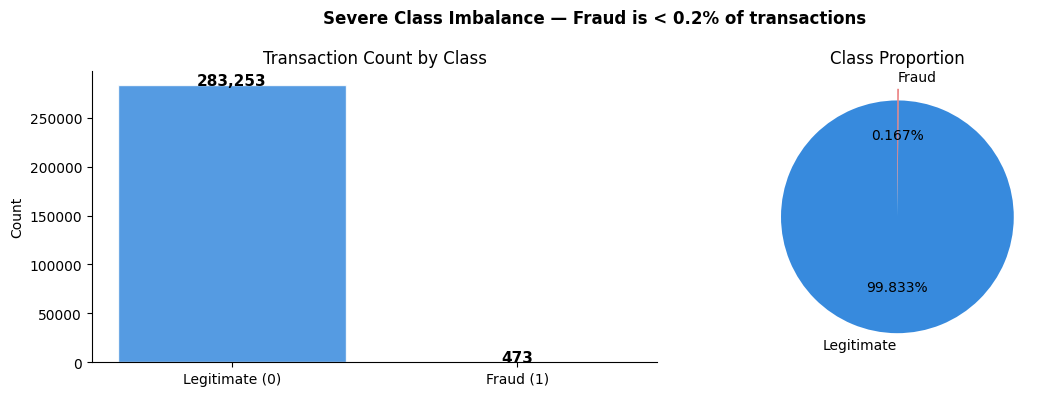

In [7]:
print("Class value counts:")
print(data['Class'].value_counts())
print(f"\nFraud rate: {data['Class'].mean()*100:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = data['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['#378ADD', '#E24B4A'], alpha=0.85, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title("Transaction Count by Class", fontsize=12)
axes[0].set_ylabel("Count")
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['#378ADD', '#E24B4A'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title("Class Proportion", fontsize=12)

plt.suptitle("Severe Class Imbalance — Fraud is < 0.2% of transactions",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Feature distributions — all numeric columns

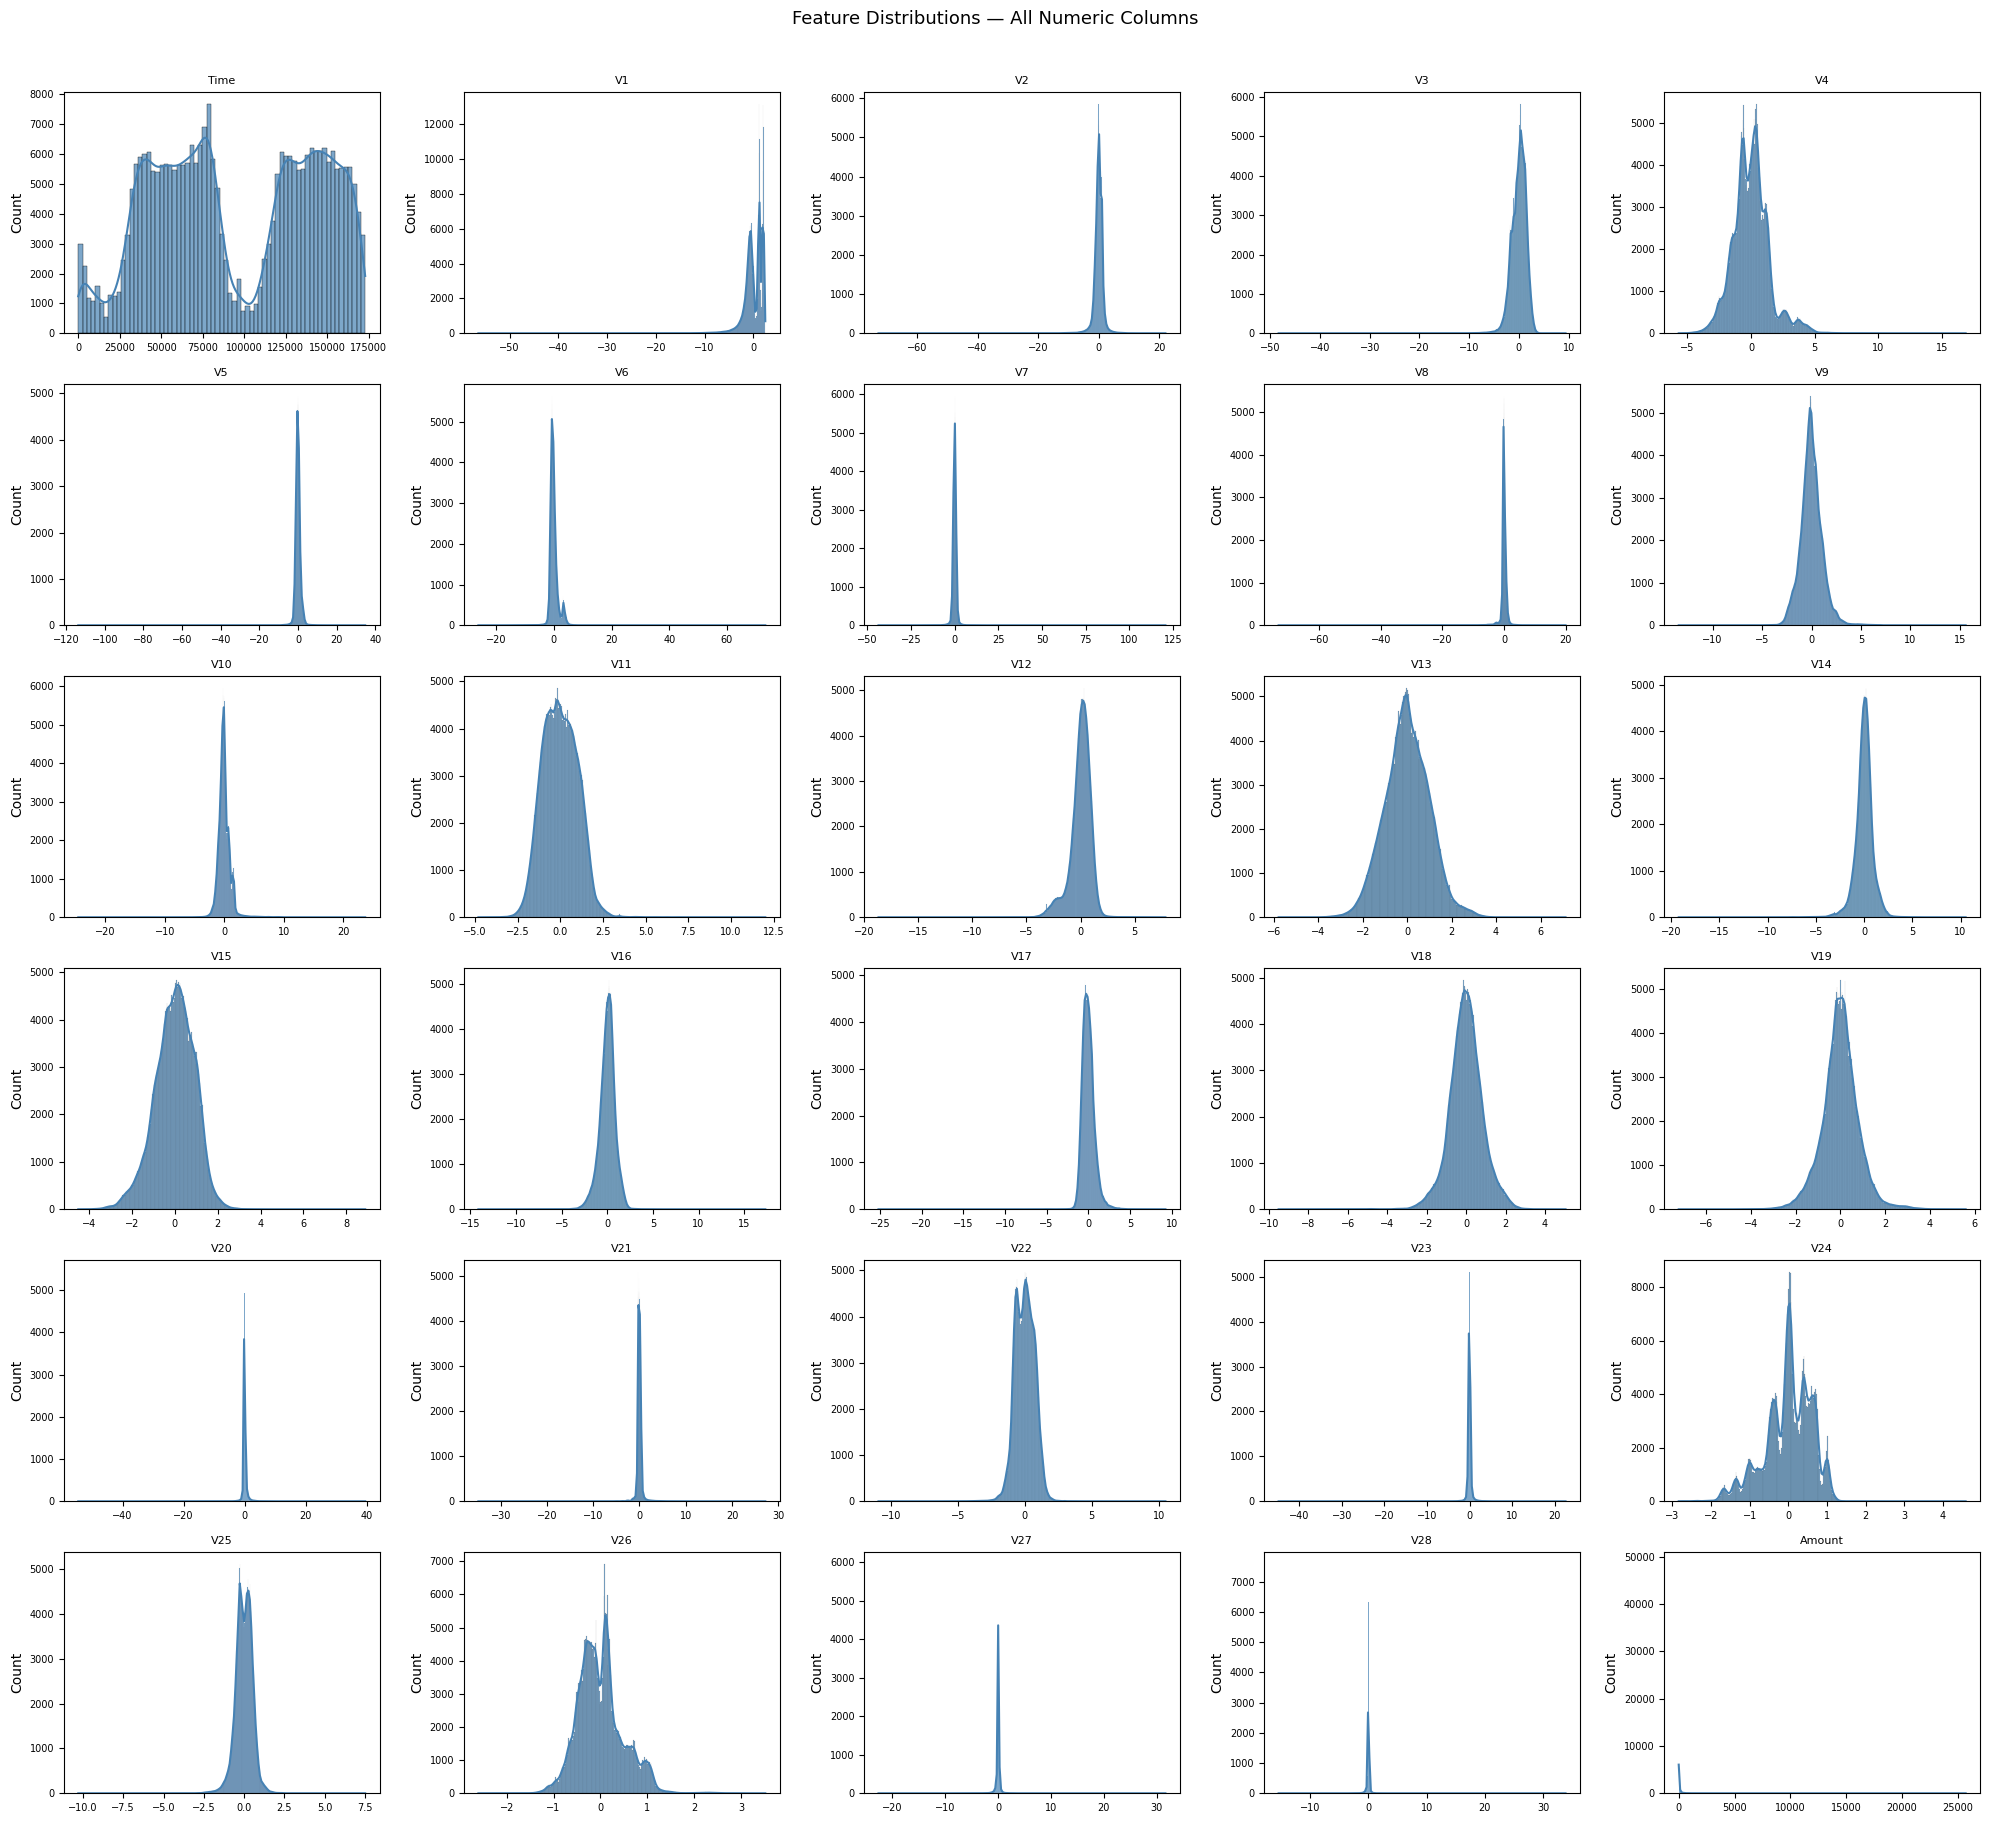


Skewness (sorted by absolute value):
Amount    16.979
V28       11.555
V8        -8.311
V23       -5.867
V2        -4.695
V17       -3.690
V1        -3.273
V7         2.890
V21        2.820
V5        -2.414
V12       -2.199
V3        -2.152
V20       -2.043
V14       -1.919
V6         1.830
V10        1.253
V16       -1.051
V27       -0.754
V4         0.672
V26        0.580
V24       -0.552
V9         0.538
V25       -0.416
V11        0.344
V15       -0.310
V18       -0.249
V22       -0.182
V19        0.108
V13        0.064
Time      -0.036


In [8]:
numeric_cols = [c for c in data.columns if c != 'Class']

n = len(numeric_cols)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions — All Numeric Columns", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("\nSkewness (sorted by absolute value):")
skew = data[numeric_cols].skew().sort_values(key=abs, ascending=False)
print(skew.round(3).to_string())

### 2.4 Fraud vs Legitimate — key feature comparison

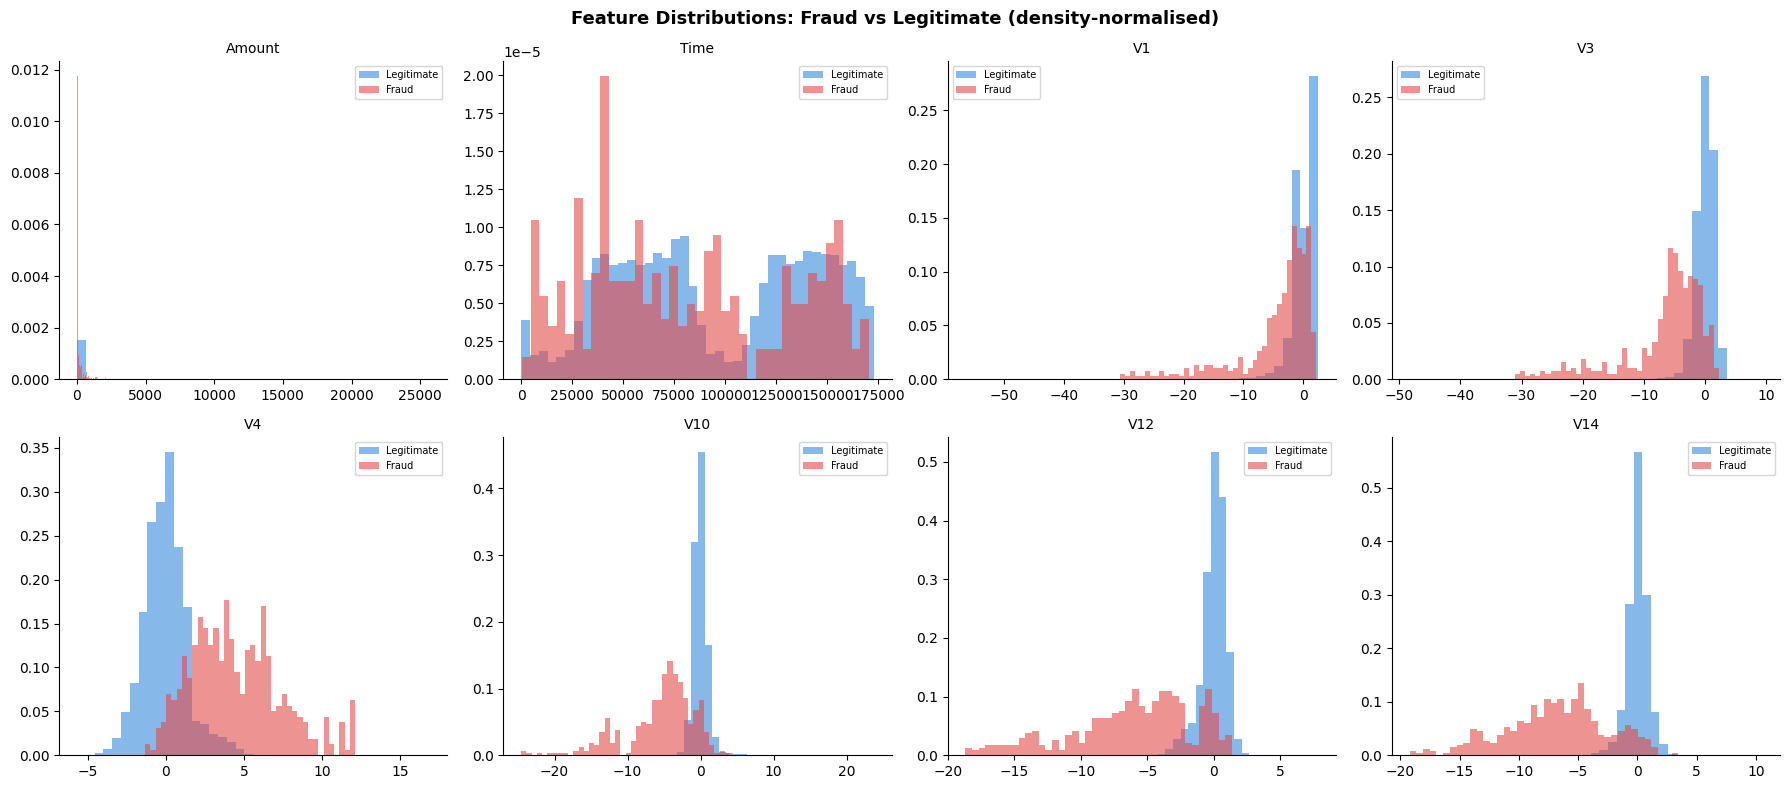

In [9]:
fraud_df = data[data['Class'] == 1]
legit_df = data[data['Class'] == 0]

compare_cols = ['Amount', 'Time', 'V1', 'V3', 'V4', 'V10', 'V12', 'V14']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    axes[i].hist(legit_df[col].dropna(), bins=40, alpha=0.6,
                 label='Legitimate', color='#378ADD', density=True)
    axes[i].hist(fraud_df[col].dropna(), bins=40, alpha=0.6,
                 label='Fraud', color='#E24B4A', density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle("Feature Distributions: Fraud vs Legitimate (density-normalised)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Transaction Amount analysis by class

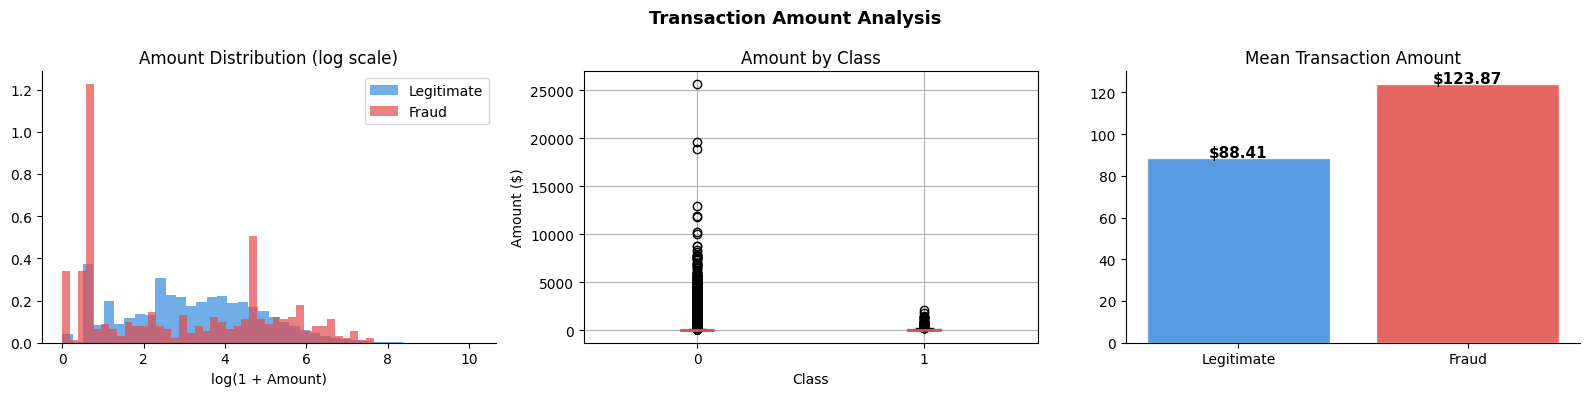

Mean amount — Legitimate: $88.41 | Fraud: $123.87
Median amount — Legitimate: $22.00 | Fraud: $9.82


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Log-scale amount distribution
axes[0].hist(np.log1p(legit_df['Amount']), bins=40, alpha=0.7,
             label='Legitimate', color='#378ADD', density=True)
axes[0].hist(np.log1p(fraud_df['Amount']), bins=40, alpha=0.7,
             label='Fraud', color='#E24B4A', density=True)
axes[0].set_xlabel("log(1 + Amount)")
axes[0].set_title("Amount Distribution (log scale)")
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Boxplot by class
data.boxplot(column='Amount', by='Class', ax=axes[1],
             boxprops=dict(color='#378ADD'),
             medianprops=dict(color='#E24B4A', lw=2))
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Amount ($)")
plt.sca(axes[1])
plt.title("Amount by Class")

# Mean amount
mean_amt = data.groupby('Class')['Amount'].mean()
axes[2].bar(['Legitimate', 'Fraud'], mean_amt.values,
            color=['#378ADD', '#E24B4A'], alpha=0.85, edgecolor='white')
for i, v in enumerate(mean_amt.values):
    axes[2].text(i, v + 0.5, f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title("Mean Transaction Amount")
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle("Transaction Amount Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean amount — Legitimate: ${legit_df['Amount'].mean():.2f} | Fraud: ${fraud_df['Amount'].mean():.2f}")
print(f"Median amount — Legitimate: ${legit_df['Amount'].median():.2f} | Fraud: ${fraud_df['Amount'].median():.2f}")

### 2.6 Correlation heatmap

Top 15 features most correlated with Class:
V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V11    0.1491
V4     0.1293
V18   -0.1053
V1    -0.0945
V9    -0.0940
V5    -0.0878
V2     0.0846
V6    -0.0439


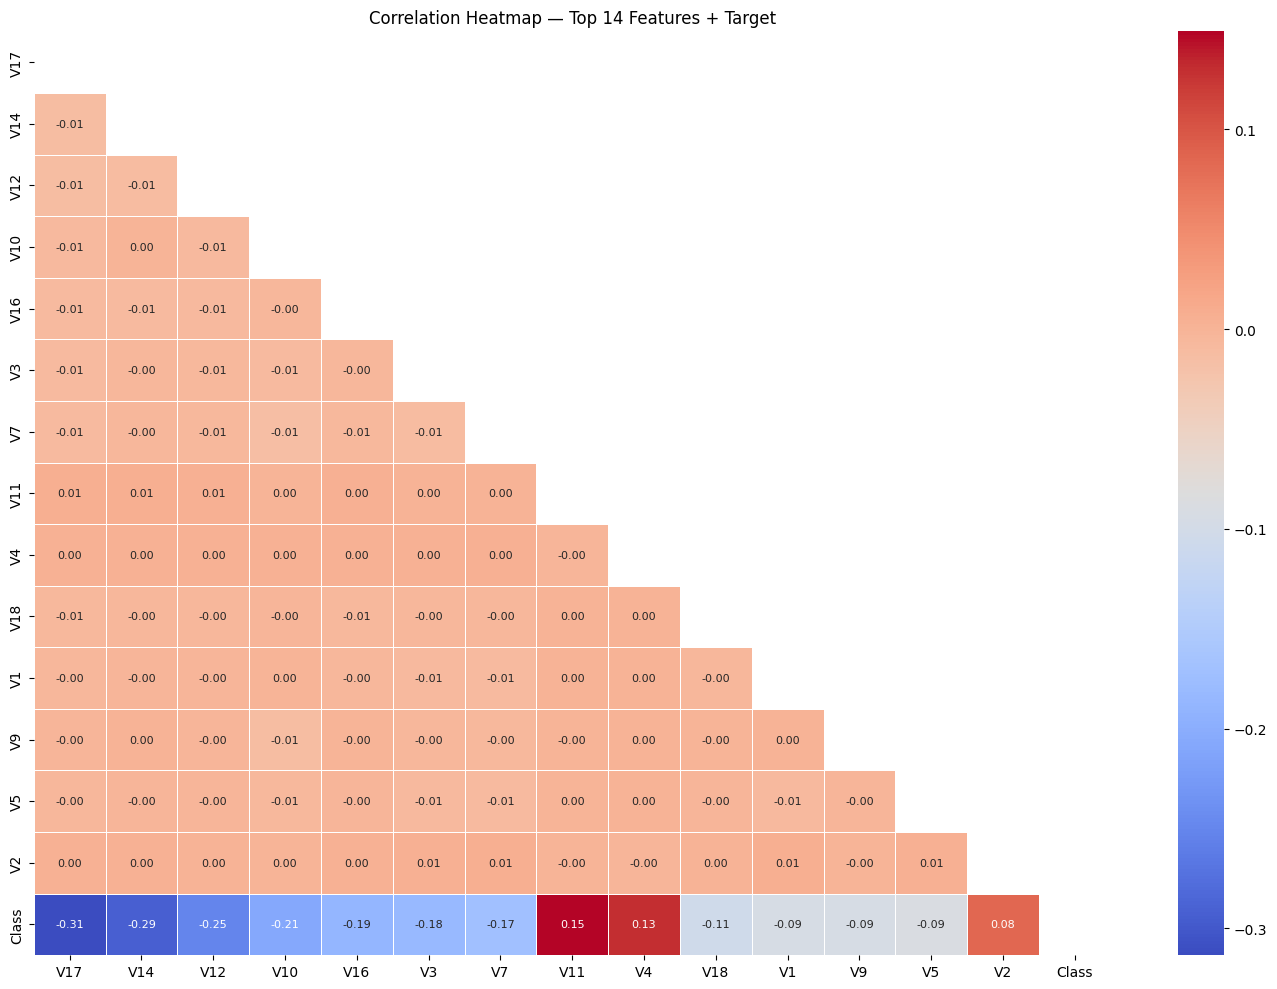

In [11]:
# Focus on features most correlated with Class
corr = data.corr()
target_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("Top 15 features most correlated with Class:")
print(target_corr.head(15).round(4).to_string())

# Heatmap of top 15 features + Class
top_feats = target_corr.head(14).index.tolist() + ['Class']
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones((len(top_feats), len(top_feats)), dtype=bool))
sns.heatmap(data[top_feats].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask, linewidths=0.5, annot_kws={'size': 8})
plt.title("Correlation Heatmap — Top 14 Features + Target", fontsize=12)
plt.tight_layout()
plt.show()

### 2.7 Time analysis & outlier boxplots

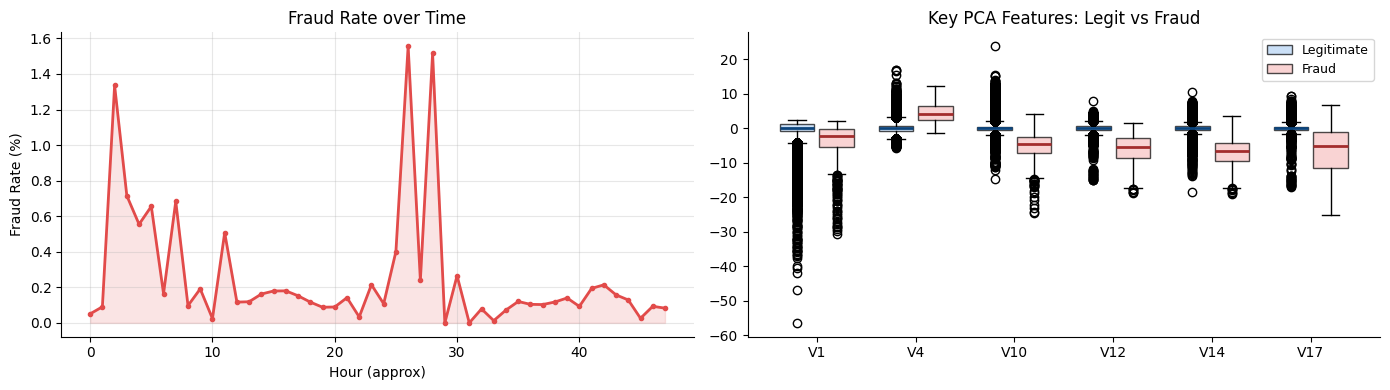

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fraud rate across time bins
data['time_hour'] = (data['Time'] // 3600) % 48
time_fraud = data.groupby('time_hour')['Class'].mean() * 100
axes[0].plot(time_fraud.index, time_fraud.values,
             color='#E24B4A', lw=2, marker='o', markersize=3)
axes[0].fill_between(time_fraud.index, time_fraud.values, alpha=0.15, color='#E24B4A')
axes[0].set_xlabel("Hour (approx)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_title("Fraud Rate over Time")
axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Key PCA feature boxplots by class
key_pca = ['V1', 'V4', 'V10', 'V12', 'V14', 'V17']
positions = np.arange(len(key_pca))
bp0 = axes[1].boxplot([legit_df[c] for c in key_pca], positions=positions - 0.2,
                       widths=0.35, patch_artist=True,
                       boxprops=dict(facecolor='#B5D4F4', alpha=0.7),
                       medianprops=dict(color='#0C447C', lw=2), notch=False)
bp1 = axes[1].boxplot([fraud_df[c] for c in key_pca], positions=positions + 0.2,
                       widths=0.35, patch_artist=True,
                       boxprops=dict(facecolor='#F7C1C1', alpha=0.7),
                       medianprops=dict(color='#A32D2D', lw=2), notch=False)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(key_pca)
axes[1].set_title("Key PCA Features: Legit vs Fraud")
axes[1].legend([bp0['boxes'][0], bp1['boxes'][0]], ['Legitimate', 'Fraud'], fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Preprocessing

### 3.1 Train/test split

In [13]:
target_col = 'Class'
X = data.drop('time_hour', axis=1, errors='ignore').drop(target_col, axis=1)
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test  fraud rate: {y_test.mean()*100:.4f}%")

Train: 226,980 | Test: 56,746
Train fraud rate: 0.1665%
Test  fraud rate: 0.1674%


### 3.2 Scaling — Time and Amount only

In [14]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")

Scaling complete.
X_train_scaled shape: (226980, 30)
X_test_scaled  shape: (56746, 30)


### 3.3 SMOTE oversampling

SMOTE applied.
Before SMOTE: Counter({0: 226602, 1: 378})
After  SMOTE: Counter({0: 226602, 1: 226602})


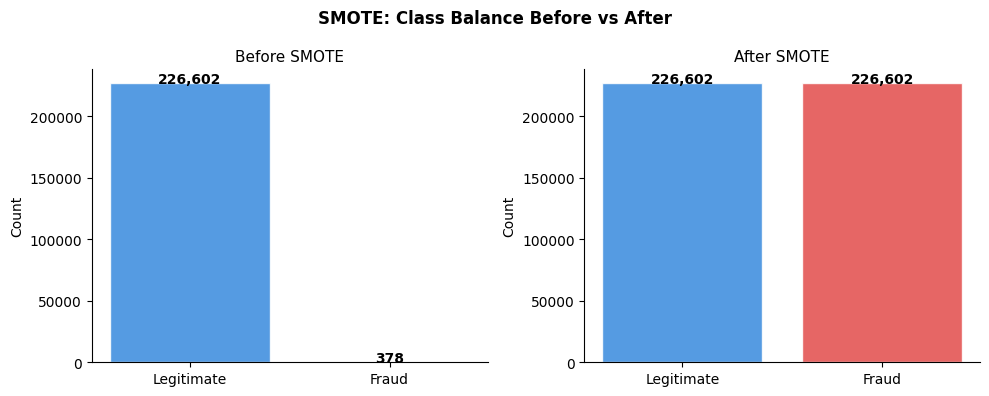

In [15]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

print("SMOTE applied.")
print(f"Before SMOTE: {Counter(y_train)}")
print(f"After  SMOTE: {Counter(y_train_resampled)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (Counter(y_train),            "Before SMOTE"),
    (Counter(y_train_resampled),  "After SMOTE")
]):
    ax.bar(['Legitimate', 'Fraud'], [counts[0], counts[1]],
           color=['#378ADD', '#E24B4A'], alpha=0.85, edgecolor='white')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Count")
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("SMOTE: Class Balance Before vs After", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. `evaluate_model()` — Per-Model Evaluation Function

Called after every model. Produces:
- Printed classification report + key metrics
- Overfit gap (train vs test accuracy)
- 3-panel figure: Confusion matrix · ROC curve with AUC fill · Metric bar chart

Returns a metrics dict appended to a results list for later comparison.

In [16]:
def evaluate_model(model, X_test, y_test, model_name="Model",
                   X_train=None, y_train=None, y_proba=None):
    """
    Full per-model evaluation with 3-panel visualisation.
    """
    y_pred = model.predict(X_test)
    if hasattr(y_pred, 'ravel'):
        y_pred = (
            (y_pred.ravel() > 0.5).astype(int)
            if y_pred.ndim > 1 or y_pred.dtype == float
            else y_pred
        )

    if y_proba is None:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = y_pred.astype(float)

    acc = accuracy_score(y_test, y_pred)
    prec_fraud = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_fraud = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_fraud = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = float('nan')

    print(f"\n{'='*65}")
    print(f"  {model_name}")
    print(f"{'='*65}")
    print(f"  Accuracy         : {acc:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")

    if X_train is not None and y_train is not None:
        try:
            train_pred = model.predict(X_train)
            if hasattr(train_pred, 'ravel'):
                train_pred = (
                    (train_pred.ravel() > 0.5).astype(int)
                    if train_pred.ndim > 1 or train_pred.dtype == float
                    else train_pred
                )
            train_acc = accuracy_score(y_train, train_pred)
            gap = train_acc - acc
            flag = " OVERFIT" if gap > 0.05 else " healthy"
            print(f"  Train Accuracy   : {train_acc:.4f}")
            print(f"  Overfit gap      : {gap:.4f}{flag}")
        except Exception:
            pass

    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1 — Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(
        ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"Confusion Matrix\n{model_name}", fontsize=10)

    # Panel 2 — ROC curve
    try:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[1].plot(fpr, tpr, color='#E24B4A', lw=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
        axes[1].fill_between(fpr, tpr, alpha=0.08, color='#E24B4A')
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title(f"ROC Curve — {model_name}", fontsize=10)
        axes[1].legend(fontsize=10)
        axes[1].grid(alpha=0.3)
        axes[1].spines[['top','right']].set_visible(False)
    except Exception:
        axes[1].text(0.5, 0.5, 'ROC N/A', ha='center', va='center')

    # Panel 3 — Metric bar chart
    metric_names = ['Accuracy', 'Precision\n(Fraud)', 'Recall\n(Fraud)',
                    'F1\n(Fraud)', 'ROC-AUC']
    metric_values = [acc, prec_fraud, recall_fraud, f1_fraud,auc if not np.isnan(auc) else 0]
    bar_colors = ['#378ADD','#1D9E75','#7B5EA7','#D85A30','#BA7517']
    bars = axes[2].bar(metric_names, metric_values, color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, metric_values):
        if v is not None and not np.isnan(v):
            axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                         f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    axes[2].set_ylim(0, 1.18)
    axes[2].set_ylabel("Score")
    axes[2].set_title(f"Metric Summary — {model_name}", fontsize=10)
    axes[2].set_xticklabels(metric_names, rotation=25, ha='right', fontsize=8)
    axes[2].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f"{'='*65}\n")

    # Return dictionary with BOTH F1 metrics
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec_fraud,
        'Recall': recall_fraud,
        'F1': f1_fraud,           # For fraud class (used in ranking)
        'F1 (wtd)': f1_weighted,  # Weighted average (for completeness)
        'ROC-AUC': auc if not np.isnan(auc) else None,
        '_y_proba': y_proba
    }

## 5. `plot_all_models()` — Cross-Model Dashboard Function

Call once after all models in a section are trained. Produces a 5-panel dashboard:
- Grouped metric bars (Accuracy, Precision, Recall, F1, ROC-AUC)
- ROC overlay for all models
- Precision-Recall overlay
- Metric heatmap
- F1 ranking bar (best to worst)

In [17]:
def plot_all_models(results, y_test_labels, tag=""):
    """
    Single-condition dashboard — FIXED VERSION with proper F1 display
    """
    # Remove duplicates first
    seen_models = set()
    unique_results = []
    for r in results:
        if r['Model'] not in seen_models:
            seen_models.add(r['Model'])
            unique_results.append(r)
    results = unique_results

    n = len(results)
    model_labels = [r['Model'].replace(f' ({tag})','').replace(' (No SMOTE)','').replace(' (SMOTE)','')
                    for r in results]

    _PALETTE = ['#2E75B6','#BA7517','#1D9E75','#D85A30','#7F77DD',
            '#D4537E','#E24B4A','#2E8B74','#7B5EA7','#378ADD','#F4A0A0']
    # Metrics to display
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    colors_m = ['#378ADD', '#1D9E75', '#7B5EA7', '#D85A30', '#E24B4A']

    # Debug: Print F1 values to verify they're not zero
    print(f"\n{'='*50}")
    print(f"DEBUG: {tag} - F1 Values Check")
    print(f"{'='*50}")
    for r in results:
        print(f"{r['Model']}: F1 = {r.get('F1', 'MISSING'):.4f}")
    print(f"{'='*50}\n")

    title_tag = f" — {tag}" if tag else ""
    fig = plt.figure(figsize=(22, 28))
    fig.suptitle(f"All-Models Evaluation Dashboard{title_tag}", fontsize=16, fontweight='bold', y=1.005)

    gs = fig.add_gridspec(5, 2, hspace=0.55, wspace=0.35)

    # ── Panel A: grouped metric bars ──────────────────────────────
    ax_bars = fig.add_subplot(gs[0, :])
    x = np.arange(n)
    width = 0.15
    offsets = np.linspace(-(len(metrics)-1)/2*width, (len(metrics)-1)/2*width, len(metrics))

    for mi, (met, col, off) in enumerate(zip(metrics, colors_m, offsets)):
        vals = [r.get(met, 0) for r in results]
        bars = ax_bars.bar(x + off, vals, width, label=met, color=col, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax_bars.text(bar.get_x()+bar.get_width()/2, v+0.005,
                         f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold')

    ax_bars.set_xticks(x)
    ax_bars.set_xticklabels(model_labels, rotation=35, ha='right', fontsize=9)
    ax_bars.set_ylim(0, 1.30)
    ax_bars.set_ylabel("Score")
    ax_bars.set_title(f"All Metrics — All Models{title_tag}", fontsize=12, fontweight='bold')
    ax_bars.legend(loc='upper right', fontsize=9, ncol=5)
    ax_bars.spines[['top','right']].set_visible(False)
    ax_bars.axhline(y=0.5, color='grey', lw=0.8, ls='--', alpha=0.5)

    # ── Panel B: overlay ROC curves ───────────────────────────────
    ax_roc = fig.add_subplot(gs[1, 0])
    ax_roc.plot([0,1],[0,1],'k--',lw=0.8, alpha=0.5, label='Random (AUC=0.500)')

    for i, r in enumerate(results):
        if '_y_proba' in r and r['_y_proba'] is not None:
            try:
                fpr, tpr, _ = roc_curve(y_test_labels, r['_y_proba'])
                auc_v = r.get('ROC-AUC') or 0
                ax_roc.plot(fpr, tpr, lw=1.8, color=_PALETTE[i % len(_PALETTE)],
                            label=f"{model_labels[i]} ({auc_v:.3f})")
            except Exception:
                pass

    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"ROC Curves — All Models{title_tag}", fontsize=11, fontweight='bold')
    ax_roc.legend(fontsize=7, loc='lower right', framealpha=0.7)
    ax_roc.grid(alpha=0.3)
    ax_roc.spines[['top','right']].set_visible(False)

    # ── Panel C: overlay Precision-Recall curves ──────────────────
    from sklearn.metrics import precision_recall_curve, average_precision_score
    ax_pr = fig.add_subplot(gs[1, 1])

    for i, r in enumerate(results):
        if '_y_proba' in r and r['_y_proba'] is not None:
            try:
                prec_c, rec_c, _ = precision_recall_curve(y_test_labels, r['_y_proba'])
                ap = average_precision_score(y_test_labels, r['_y_proba'])
                ax_pr.plot(rec_c, prec_c, lw=1.8, color=_PALETTE[i % len(_PALETTE)],
                           label=f"{model_labels[i]} (AP={ap:.3f})")
            except Exception:
                pass

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"Precision-Recall Curves — All Models{title_tag}", fontsize=11, fontweight='bold')
    ax_pr.legend(fontsize=7, loc='upper right', framealpha=0.7)
    ax_pr.grid(alpha=0.3)
    ax_pr.spines[['top','right']].set_visible(False)

    # ── Panel D: metric heatmap ───────────────────────────────────
    ax_heat = fig.add_subplot(gs[2, :])
    heat_data = np.array([[r.get(m, 0) for m in metrics] for r in results])
    im = ax_heat.imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    ax_heat.set_xticks(range(len(metrics)))
    ax_heat.set_xticklabels(metrics, fontsize=10)
    ax_heat.set_yticks(range(n))
    ax_heat.set_yticklabels(model_labels, fontsize=9)

    for i in range(n):
        for j in range(len(metrics)):
            v = heat_data[i, j]
            color = 'white' if v < 0.35 or v > 0.85 else 'black'
            ax_heat.text(j, i, f'{v:.3f}', ha='center', va='center',
                         fontsize=8, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax_heat, fraction=0.02, pad=0.01)
    ax_heat.set_title(f"Metric Heatmap — All Models{title_tag}", fontsize=12, fontweight='bold')

    # ── Panel E: F1-fraud ranking bar ─────────────────────────────
    ax_rank = fig.add_subplot(gs[3:, :])  # Take bottom rows
    f1_vals = [r.get('F1', 0) for r in results]

    # Sort for ranking
    sorted_idx = np.argsort(f1_vals)[::-1]
    sorted_labels = [model_labels[i] for i in sorted_idx]
    sorted_vals = [f1_vals[i] for i in sorted_idx]
    bar_cols = [_PALETTE[i % len(_PALETTE)] for i in sorted_idx]

    bars = ax_rank.barh(range(n), sorted_vals, color=bar_cols, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, sorted_vals):
        ax_rank.text(max(v + 0.01, 0.05), bar.get_y()+bar.get_height()/2,
                     f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

    ax_rank.set_yticks(range(n))
    ax_rank.set_yticklabels(sorted_labels, fontsize=9)
    ax_rank.set_xlim(0, max(max(sorted_vals) * 1.1, 0.5))
    ax_rank.set_xlabel("F1-Score (Fraud Class)", fontsize=10)
    ax_rank.set_title(f"Model Ranking by F1 (Fraud Class){title_tag} — Best → Worst",
                      fontsize=12, fontweight='bold')
    ax_rank.axvline(x=0.5, color='grey', lw=0.8, ls='--', alpha=0.5)
    ax_rank.spines[['top','right']].set_visible(False)
    ax_rank.invert_yaxis()

    plt.tight_layout()
    plt.savefig(f"all_models_dashboard_{tag.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Dashboard saved → all_models_dashboard_{tag.replace(' ','_')}.png")

## 6. Model Training — Without SMOTE

All models trained on original imbalanced data.

| # | Model | Type |
|---|---|---|
| 1 | KNN | Classical |
| 2 | Random Forest | Ensemble |
| 3 | XGBoost | Ensemble |
| 4 | LightGBM | Ensemble |
| 5 | Gradient Boosting | Ensemble |
| 6 | Decision Tree | Classical |
| 7 | Bagging | Ensemble |
| 8 | Naive Bayes | Classical |
| 9 | Voting Classifier | Ensemble |
| 10 | CNN | Deep Learning |
| 11 | ANN | Deep Learning |

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               BaggingClassifier, VotingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

results_no_smote  = []
registry_no_smote = {}
dl_roc_no_smote   = {}

### 6.1 KNN


  KNN (Without SMOTE)
  Accuracy         : 0.9995
  ROC-AUC          : 0.8999
  Train Accuracy   : 0.9996
  Overfit gap      : 0.0001 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56649     2]
 [   28    67]]


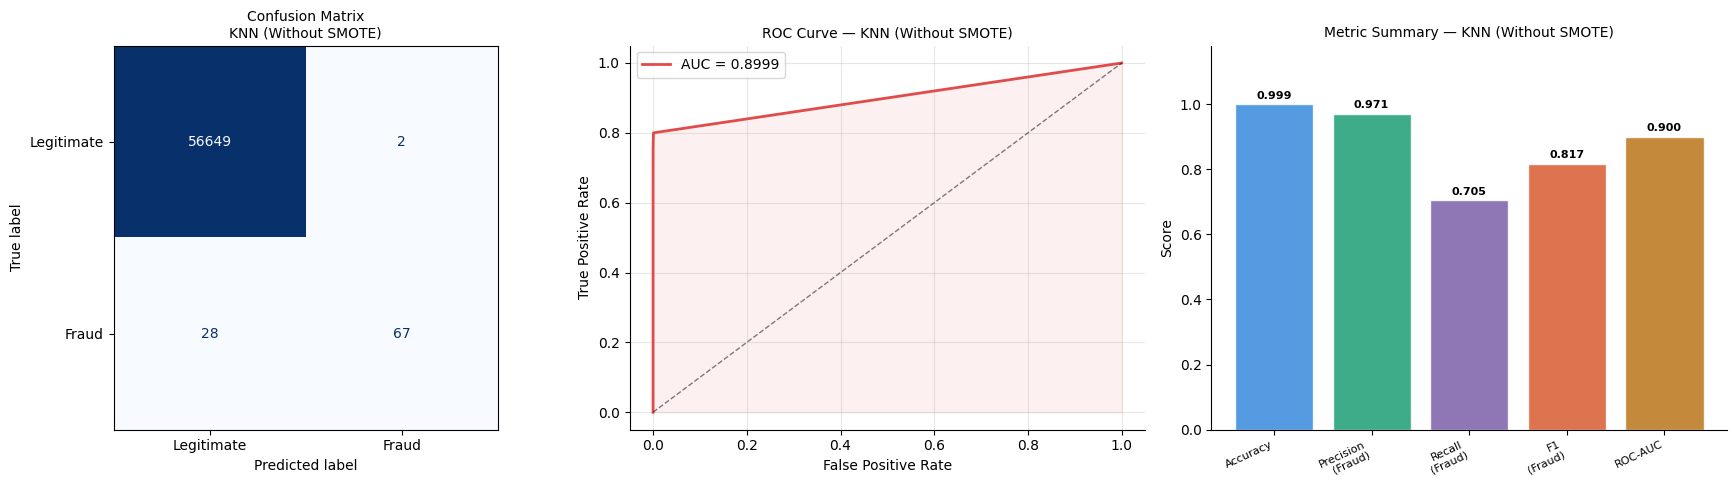

In [19]:
knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski")
knn.fit(X_train_scaled, y_train)

r = evaluate_model(knn, X_test_scaled, y_test,
                   model_name="KNN (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["KNN (Without SMOTE)"] = knn

### 6.2 Random Forest


  Random Forest (Without SMOTE)
  Accuracy         : 0.9995
  ROC-AUC          : 0.9447
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0005 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56649     2]
 [   27    68]]


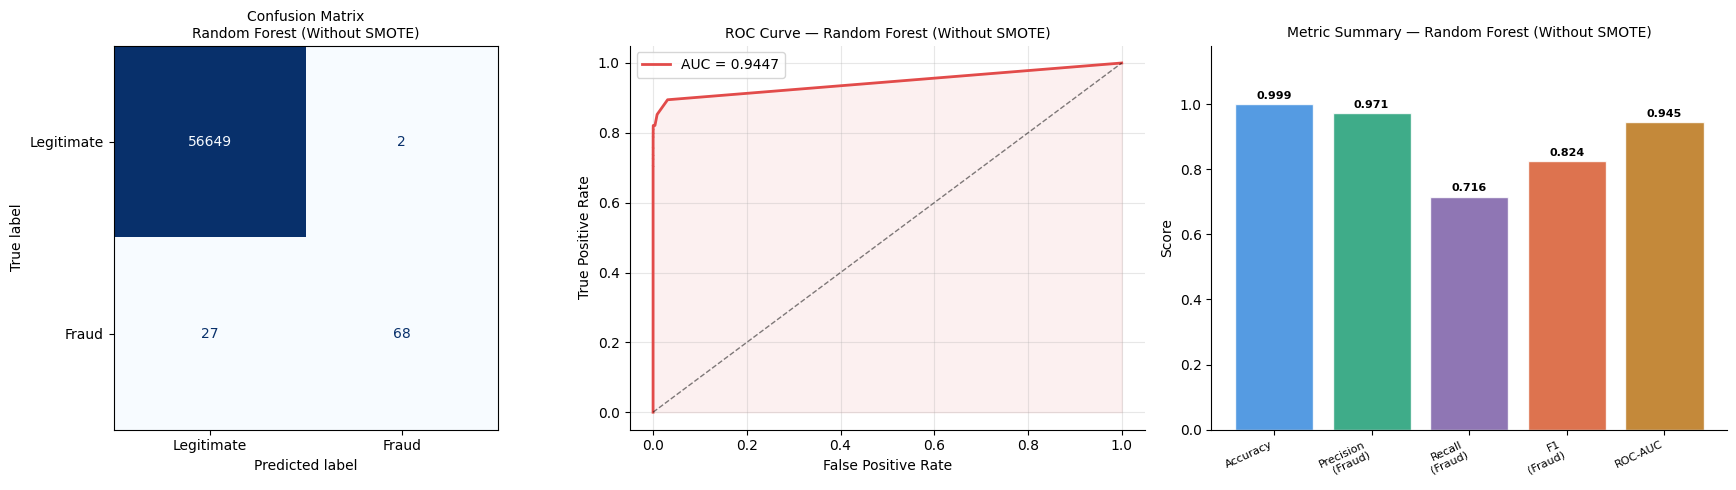

In [20]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    min_samples_split=2, min_samples_leaf=1,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

r = evaluate_model(rf, X_test_scaled, y_test,
                   model_name="Random Forest (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["Random Forest (Without SMOTE)"] = rf

### 6.3 XGBoost


  XGBoost (Without SMOTE)
  Accuracy         : 0.9995
  ROC-AUC          : 0.9691
  Train Accuracy   : 0.9999
  Overfit gap      : 0.0004 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.93      0.78      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56645     6]
 [   21    74]]


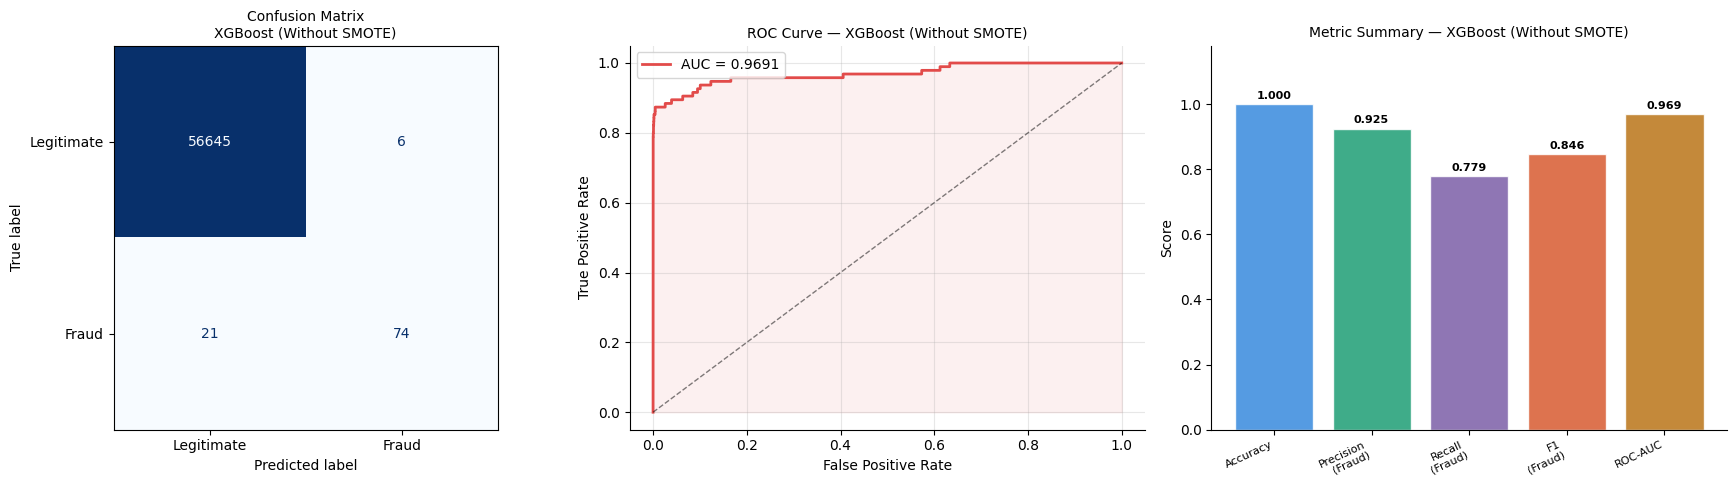

In [21]:
neg, pos = y_train.value_counts()
scale    = neg / pos

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale, eval_metric='auc', random_state=42)
xgb.fit(X_train_scaled, y_train)

r = evaluate_model(xgb, X_test_scaled, y_test,
                   model_name="XGBoost (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["XGBoost(Without SMOTE)"] = xgb

### 6.4 LightGBM

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

  LightGBM (Without SMOTE)
  Accuracy         : 0.9995
  ROC-AUC          : 0.9761
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0005 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusi

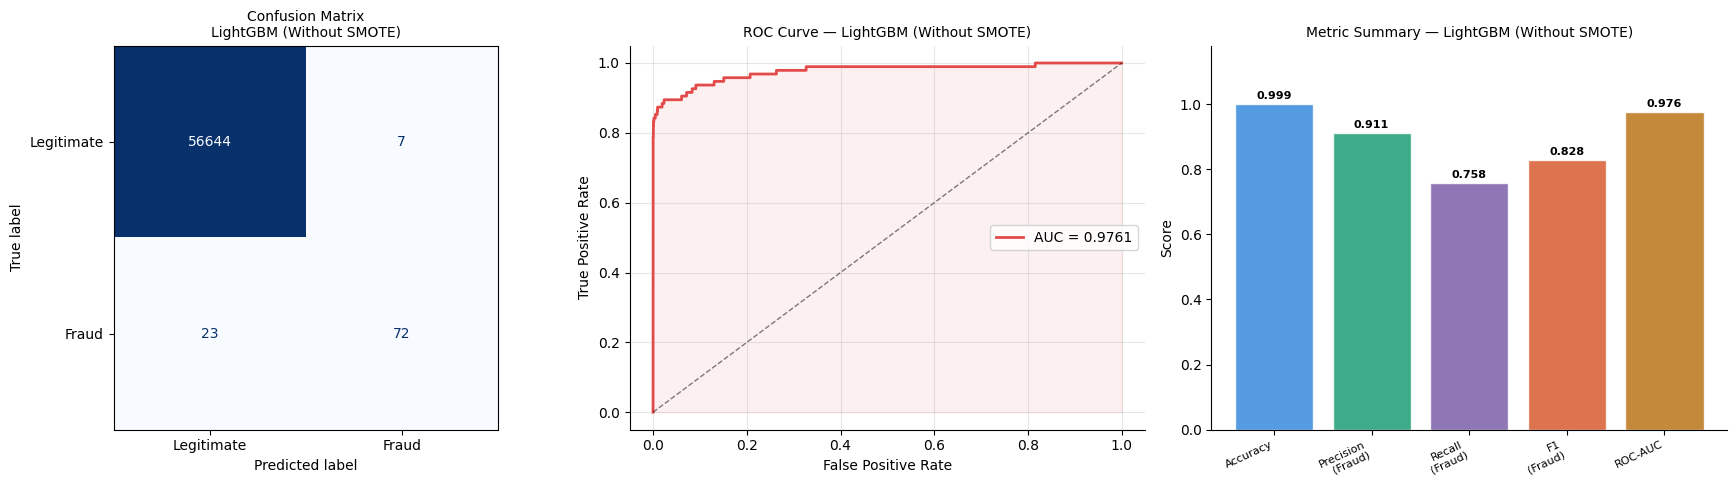

In [22]:
lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    class_weight='balanced', random_state=42)
lgbm.fit(X_train_scaled, y_train)

r = evaluate_model(lgbm, X_test_scaled, y_test,
                   model_name="LightGBM (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["LightGBM (Without SMOTE)"] = lgbm

### 6.5 Gradient Boosting


  Gradient Boosting (Without SMOTE)
  Accuracy         : 0.9993
  ROC-AUC          : 0.9264
  Train Accuracy   : 0.9997
  Overfit gap      : 0.0003 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.90      0.68      0.78        95

    accuracy                           1.00     56746
   macro avg       0.95      0.84      0.89     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56644     7]
 [   30    65]]


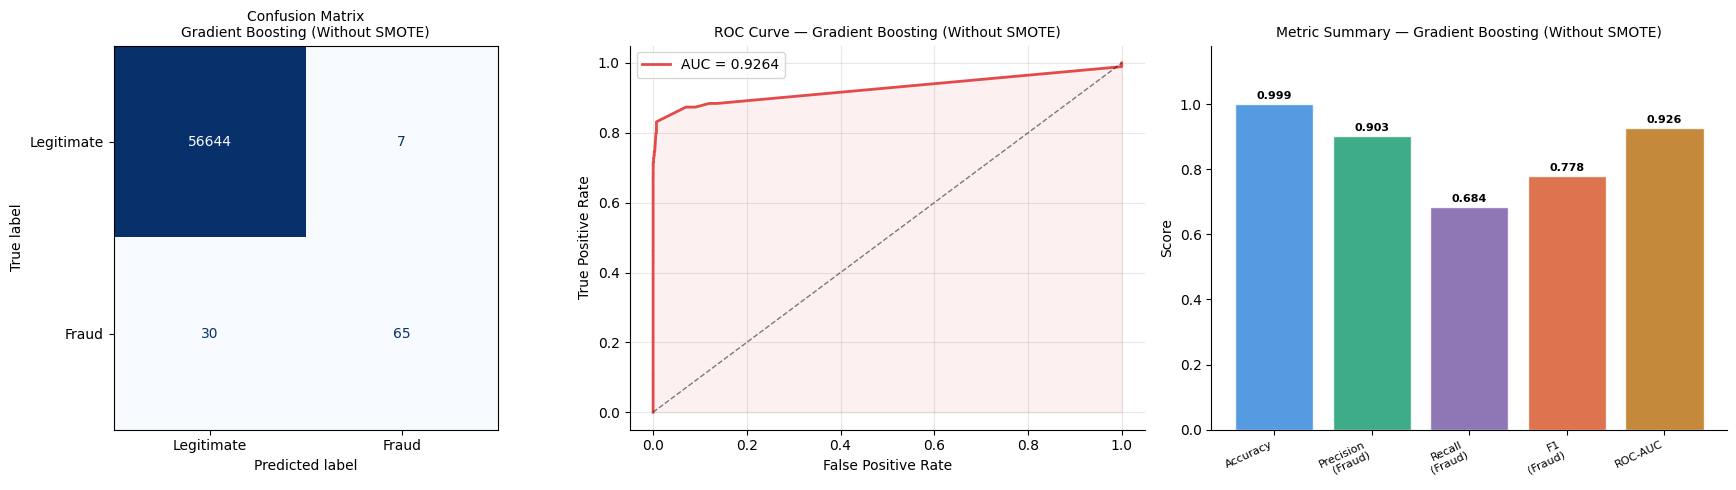

In [23]:
gbm = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gbm.fit(X_train_scaled, y_train)

r = evaluate_model(gbm, X_test_scaled, y_test,
                   model_name="Gradient Boosting (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["Gradient Boosting (Without SMOTE)"] = gbm

### 6.6 Decision Tree


  Decision Tree (Without SMOTE)
  Accuracy         : 0.9993
  ROC-AUC          : 0.9166
  Train Accuracy   : 0.9995
  Overfit gap      : 0.0002 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.86      0.68      0.76        95

    accuracy                           1.00     56746
   macro avg       0.93      0.84      0.88     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56640    11]
 [   30    65]]


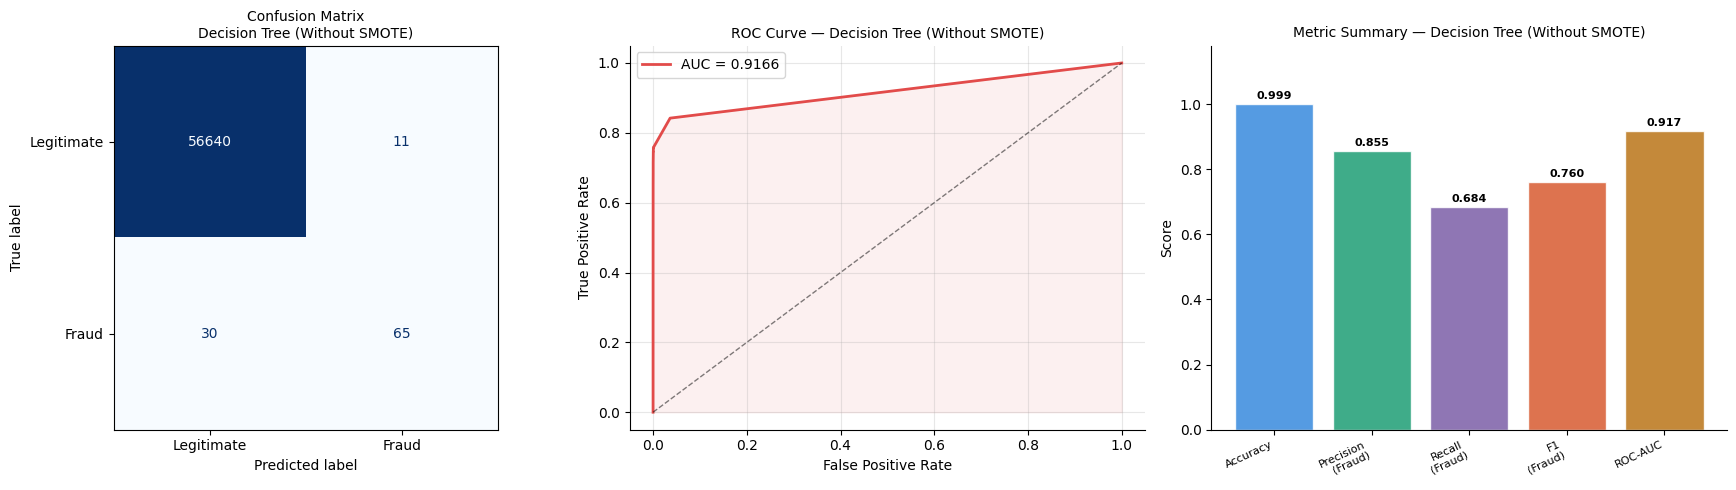

In [24]:
dt = DecisionTreeClassifier(
    criterion="gini", max_depth=6,
    min_samples_split=50, min_samples_leaf=20, random_state=42)
dt.fit(X_train_scaled, y_train)

r = evaluate_model(dt, X_test_scaled, y_test,
                   model_name="Decision Tree (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["Decision Tree (Without SMOTE)"] = dt

### 6.7 Bagging


  Bagging (Without SMOTE)
  Accuracy         : 0.9994
  ROC-AUC          : 0.9406
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0006 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.67      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56649     2]
 [   31    64]]


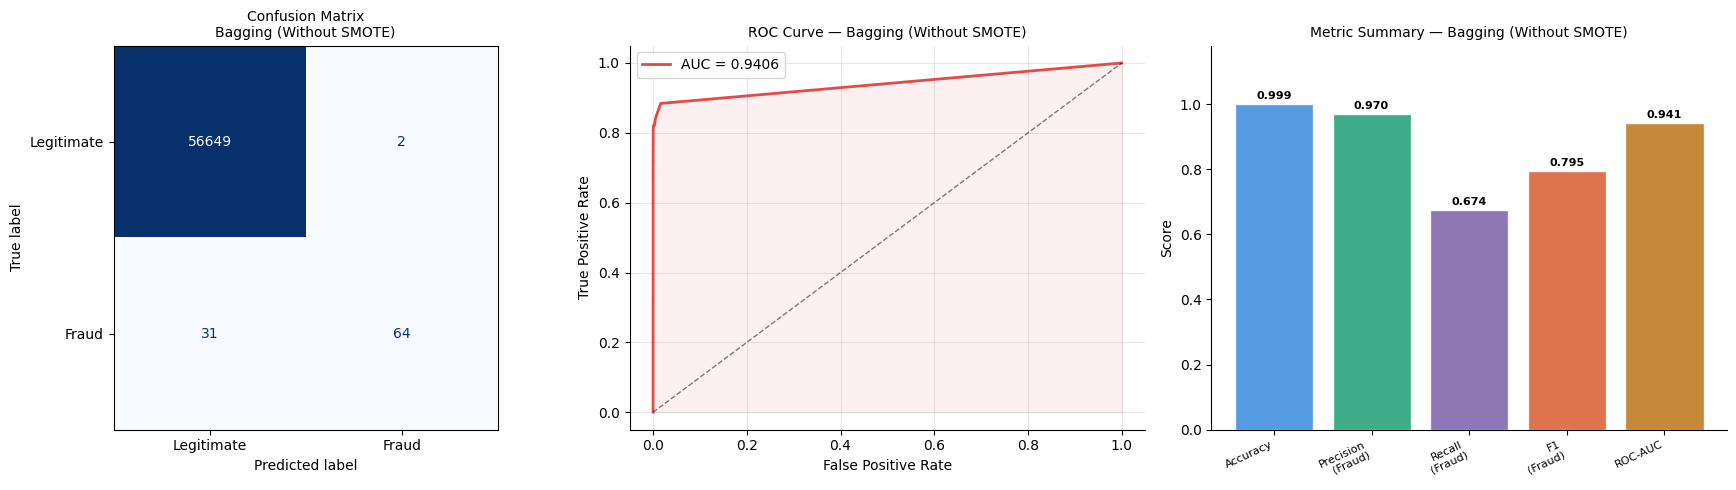

In [25]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    n_estimators=100, random_state=42, n_jobs=-1)
bagging.fit(X_train_scaled, y_train)

r = evaluate_model(bagging, X_test_scaled, y_test,
                   model_name="Bagging (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["Bagging (Without SMOTE)"] = bagging

### 6.8 Naive Bayes


  Naive Bayes (Without SMOTE)
  Accuracy         : 0.9775
  ROC-AUC          : 0.9488
  Train Accuracy   : 0.9779
  Overfit gap      : 0.0004 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.81      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.55     56746
weighted avg       1.00      0.98      0.99     56746


Confusion Matrix:
[[55395  1256]
 [   18    77]]


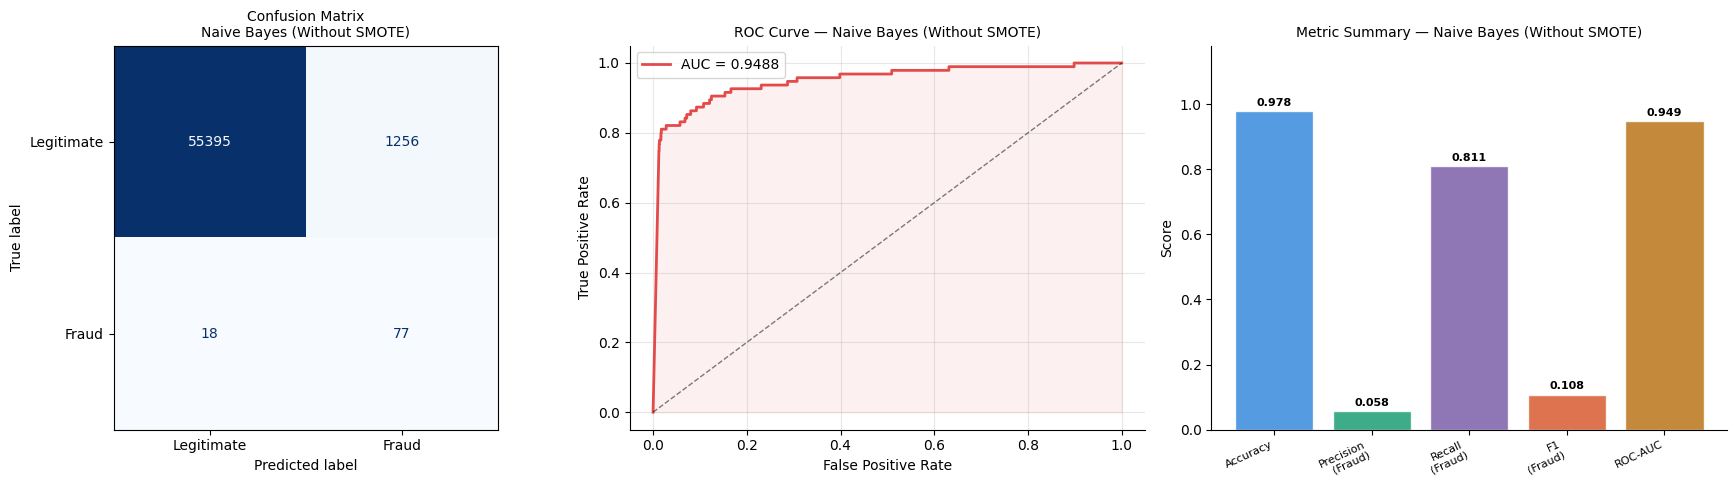

In [26]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

r = evaluate_model(nb, X_test_scaled, y_test,
                   model_name="Naive Bayes (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["Naive Bayes (Without SMOTE)"] = nb

### 6.9 Voting Classifier

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

  Voting (Without SMOTE)
  Accuracy         : 0.9995
  ROC-AUC          : 0.9738
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0005 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.96      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion

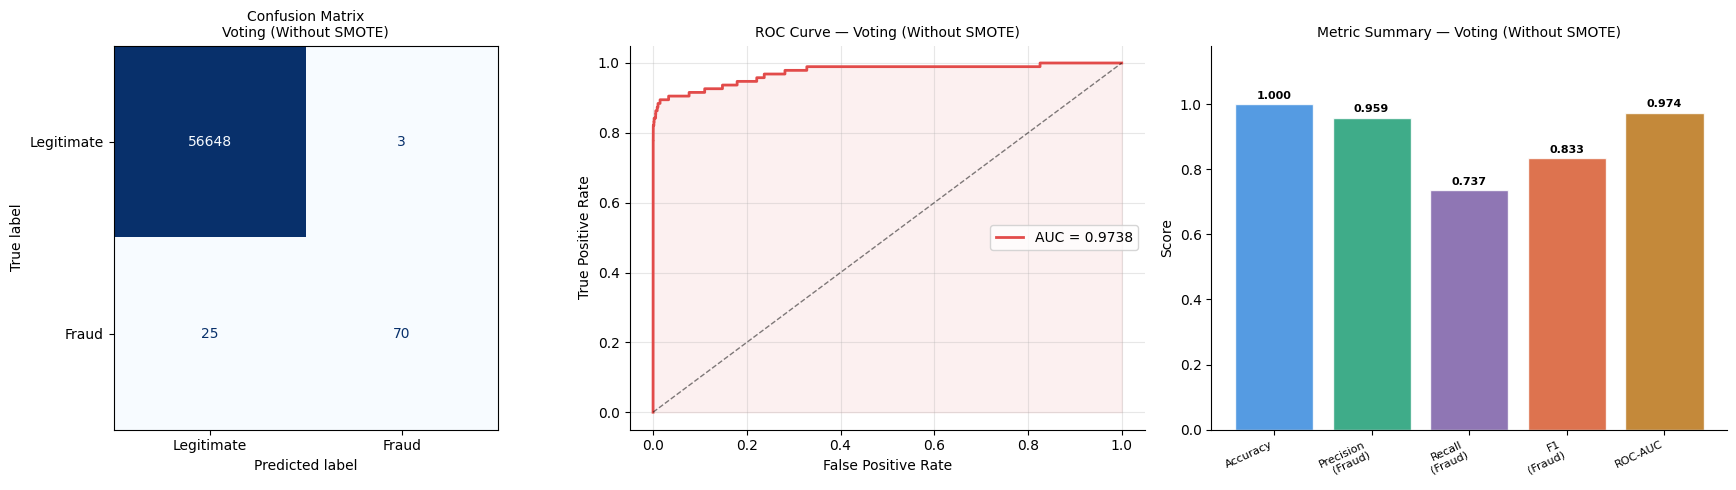

In [28]:
rf_v = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=42, n_jobs=-1)
gbm_v = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                    max_depth=3, random_state=42)
lgbm_v = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                          class_weight='balanced', random_state=42)

voting = VotingClassifier(
    estimators=[("rf", rf_v), ("gbm", gbm_v), ("lgbm", lgbm_v)],
    voting="soft")
voting.fit(X_train_scaled, y_train)

r = evaluate_model(voting, X_test_scaled, y_test,
                   model_name="Voting (Without SMOTE)",
                   X_train=X_train_scaled, y_train=y_train)
results_no_smote.append(r)
registry_no_smote["Voting (Without SMOTE)"] = voting

### 6.10 CNN (No SMOTE)

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense, Dropout,
                                      BatchNormalization, Input, LayerNormalization,
                                      MultiHeadAttention)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_recall_curve

X_train_cnn = X_train_scaled.values.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.values.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)

def focal_loss(alpha=0.5, gamma=2.0):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -alpha * tf.pow(1 - pt, gamma) * tf.math.log(pt)
    return loss

cnn_model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu',
           kernel_regularizer=l2(0.001),
           input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(), MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(), MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss=focal_loss(alpha=0.5, gamma=2),
                  metrics=['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,425 (122.75 KB)

 Trainable params: 31,233 (122.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9956 - loss: 0.0968 - val_accuracy: 0.9995 - val_loss: 0.0533
Epoch 2/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9989 - loss: 0.0389 - val_accuracy: 0.9994 - val_loss: 0.0248
Epoch 3/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9990 - loss: 0.0197 - val_accuracy: 0.9994 - val_loss: 0.0126
Epoch 4/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9991 - loss: 0.0109 - val_accuracy: 0.9994 - val_loss: 0.0073
Epoch 5/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9991 - loss: 0.0070 - val_accuracy: 0.9994 - val_loss: 0.0043
Epoch 6/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9991 - loss: 0.0049 - val_accuracy: 0.9994 - val_loss: 0.0029
Epoch 7/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9994 - val_loss: 0.0025
Epoch 8/15
710/710 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9992 - loss: 0.0036 - 

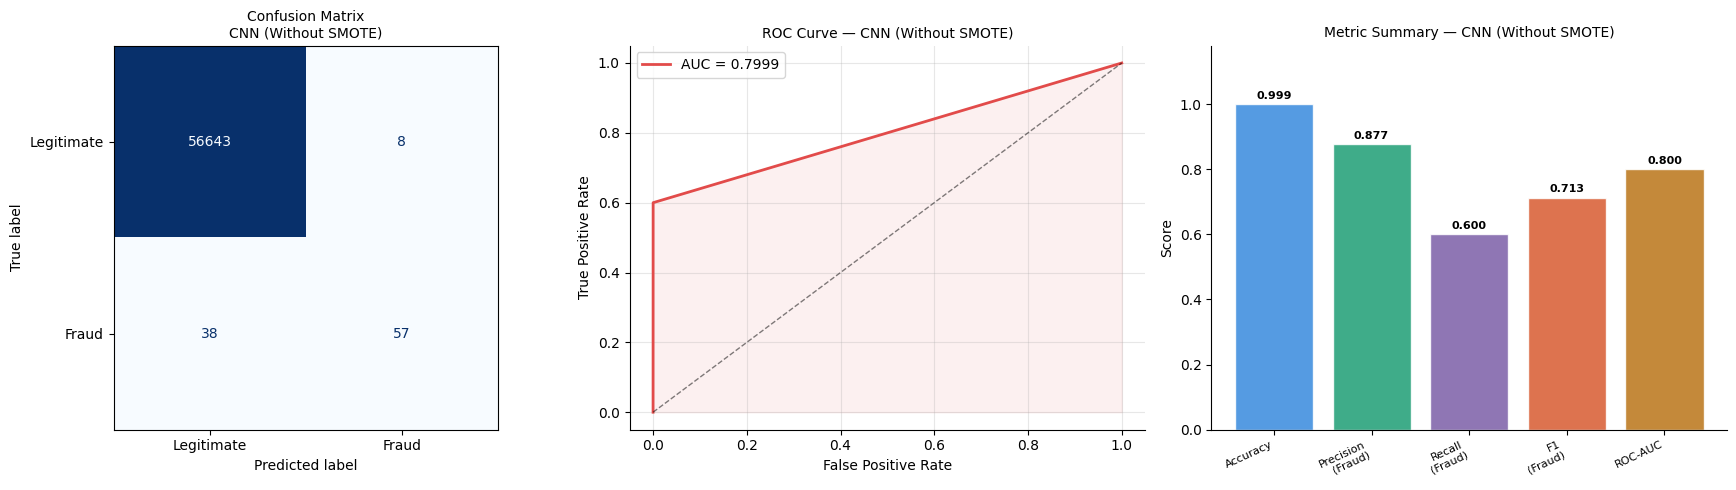

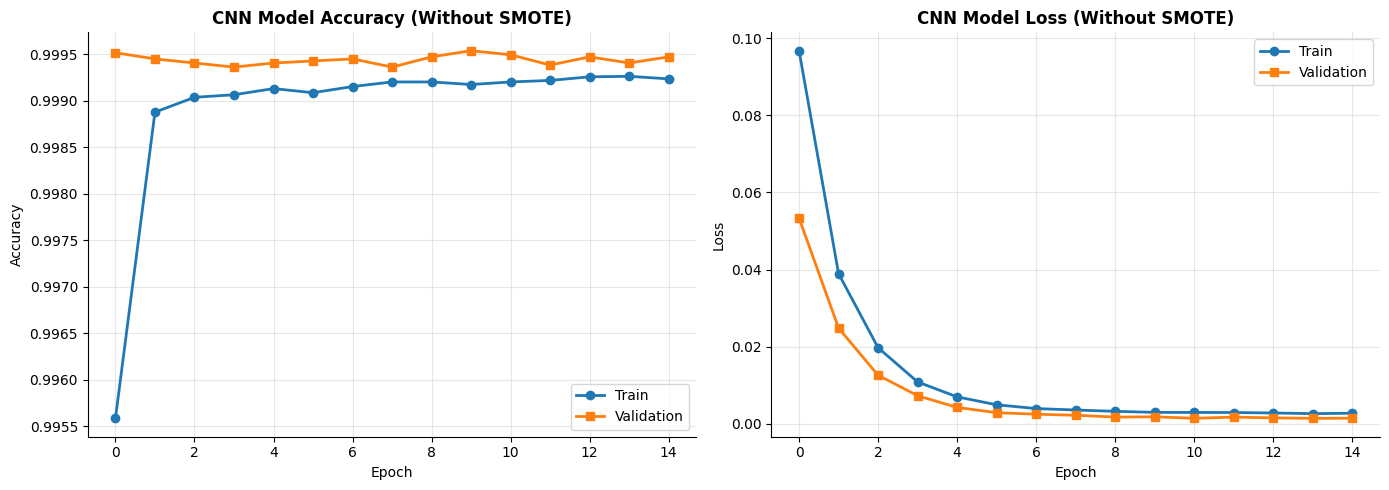

In [30]:
class_weight_dict = {0: 1.0, 1: 5.0}

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,

    class_weight=class_weight_dict,

    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

y_proba_cnn = cnn_model.predict(X_test_cnn).ravel()
r_cnn = evaluate_model(
    model       = cnn_model,
    X_test      = X_test_cnn,
    y_test      = y_test,
    model_name  = "CNN (Without SMOTE)",
)
results_no_smote.append(r_cnn)
registry_no_smote["CNN (Without SMOTE)"] = cnn_model

if hasattr(cnn_model, 'history') and cnn_model.history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot training & validation accuracy
    axes[0].plot(cnn_model.history.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(cnn_model.history.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title('CNN Model Accuracy (Without SMOTE)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    # Plot training & validation loss
    axes[1].plot(cnn_model.history.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(cnn_model.history.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title('CNN Model Loss (Without SMOTE)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

### 6.11 ANN (No SMOTE)

In [31]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}

X_train_ann = X_train_scaled.values
X_test_ann  = X_test_scaled.values

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_ann.shape[1],)),
    BatchNormalization(), Dropout(0.5),
    Dense(32, activation='relu'),
    BatchNormalization(), Dropout(0.4),
    Dense(1, activation='sigmoid')
])
ann_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])

history_ann = ann_model.fit(
    X_train_ann, y_train,
    epochs=20, batch_size=256, validation_split=0.2,
    class_weight=cw_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1)

Epoch 1/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8025 - loss: 0.3936 - val_accuracy: 0.9851 - val_loss: 0.1598
Epoch 2/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9304 - loss: 0.2523 - val_accuracy: 0.9871 - val_loss: 0.1079
Epoch 3/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9495 - loss: 0.2198 - val_accuracy: 0.9856 - val_loss: 0.0973
Epoch 4/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9587 - loss: 0.1813 - val_accuracy: 0.9862 - val_loss: 0.0892
Epoch 5/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9582 - loss: 0.1941 - val_accuracy: 0.9917 - val_loss: 0.0748
Epoch 6/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9627 - loss: 0.1687 - val_accuracy: 0.9856 - val_loss: 0.0828
Epoch 7/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9621 - loss: 0.1588 - val_accuracy: 0.9931 - val_loss: 0.0615
Epoch 8/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9694 - loss: 0.1396 - val_accuracy: 0.

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

  ANN (Without SMOTE)
  Accuracy         : 0.9914
  ROC-AUC          : 0.9221

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56651
       Fraud       0.15      0.85      0.25        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.62     56746
weighted avg       1.00      0.99      0.99     56746


Confusion Matrix:
[[56175   476]
 [   14    81]]


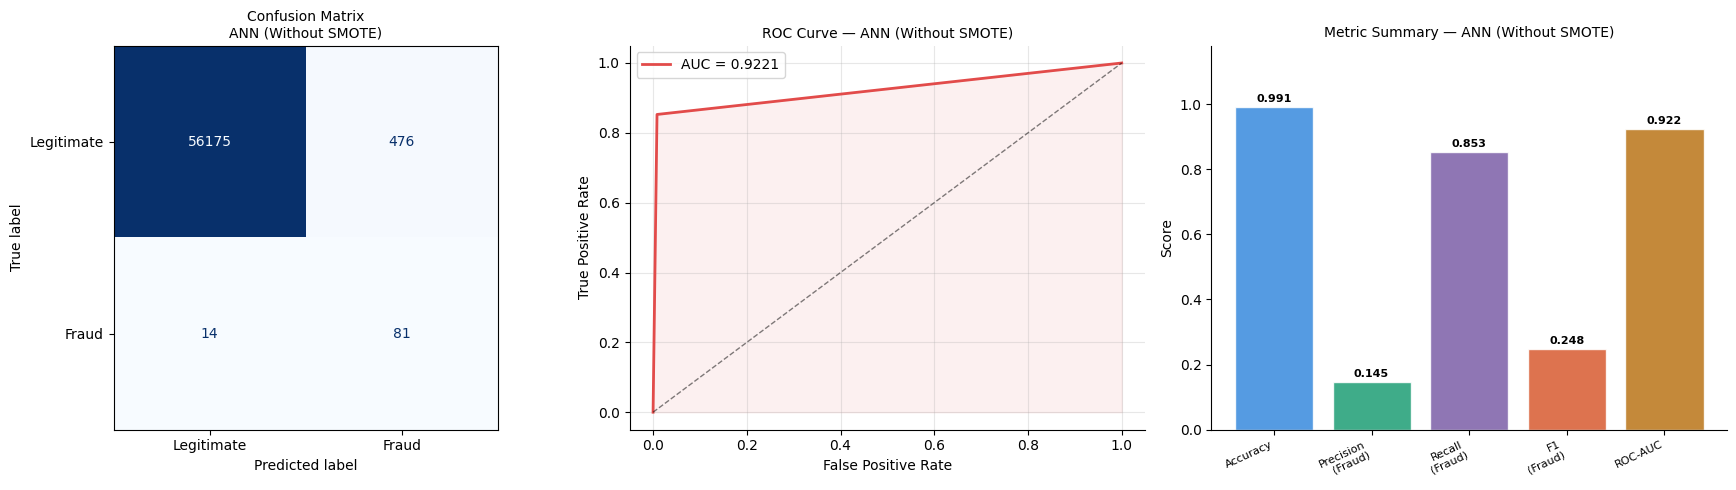

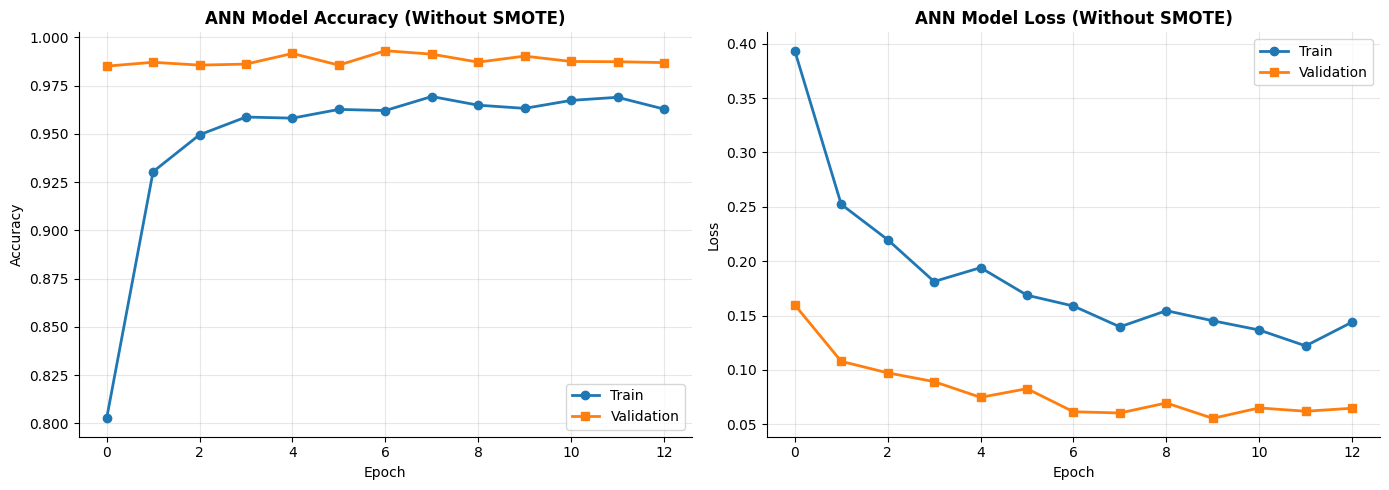

In [32]:
y_proba_ann = ann_model.predict(X_test_ann).ravel()
r_ann = evaluate_model(
    model       = ann_model,
    X_test      = X_test_ann,
    y_test      = y_test,
    model_name  = "ANN (Without SMOTE)",
)
results_no_smote.append(r_ann)
registry_no_smote["ANN (Without SMOTE)"] = ann_model

if hasattr(ann_model, 'history') and ann_model.history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

     # Plot training & validation accuracy
    axes[0].plot(history_ann.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(history_ann.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title('ANN Model Accuracy (Without SMOTE)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

     # Plot training & validation loss
    axes[1].plot(ann_model.history.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(ann_model.history.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title('ANN Model Loss (Without SMOTE)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

### 6.12 Dashboard — All models (No SMOTE)

In [33]:
# Deduplicate results_no_smote to ensure unique 'Model' names for the index
seen_models = set()
unique_results_no_smote = []
for r in results_no_smote:
    if r['Model'] not in seen_models:
        seen_models.add(r['Model'])
        unique_results_no_smote.append(r)

df_no_smote = pd.DataFrame(unique_results_no_smote).set_index('Model')

def style_results_cls(col):
    # metrics where higher value is better
    higher_is_better = ['Accuracy', 'Precision', 'Recall',
                        'F1 (wtd)', 'F1', 'ROC-AUC'] # Changed 'F1 (fraud)' to 'F1'

    if col.name in higher_is_better:
        best = col == col.max()
    else:
        best = col == col.min()

    return [
        'background-color:#d4edda; font-weight:bold'
        if x else ''
        for x in best
    ]

print("\nAll Models — Without SMOTE")

# Identify columns that should not be styled/formatted as numeric metrics
non_metric_cols = ['_y_proba']

# Create a display-ready DataFrame by dropping non-metric columns
df_no_smote_display = df_no_smote.drop(columns=[col for col in non_metric_cols if col in df_no_smote.columns])


styled_df = (
    df_no_smote_display.style
    .apply(style_results_cls, axis=0)   # explicitly column-wise
    .format("{:.4f}")                   # format all numeric columns
    .set_caption("Credit Card Fraud — No SMOTE Results")
)

display(styled_df)


All Models — Without SMOTE


,Accuracy,Precision,Recall,F1,F1 (wtd),ROC-AUC
Model,,,,,,
KNN (Without SMOTE),0.9995,0.9710,0.7053,0.8171,0.9994,0.8999
Random Forest (Without SMOTE),0.9995,0.9714,0.7158,0.8242,0.9995,0.9447
XGBoost (Without SMOTE),0.9995,0.9250,0.7789,0.8457,0.9995,0.9691
LightGBM (Without SMOTE),0.9995,0.9114,0.7579,0.8276,0.9994,0.9761
Gradient Boosting (Without SMOTE),0.9993,0.9028,0.6842,0.7784,0.9993,0.9264
Decision Tree (Without SMOTE),0.9993,0.8553,0.6842,0.7602,0.9992,0.9166
Bagging (Without SMOTE),0.9994,0.9697,0.6737,0.7950,0.9994,0.9406
Naive Bayes (Without SMOTE),0.9775,0.0578,0.8105,0.1078,0.9872,0.9488
Voting (Without SMOTE),0.9995,0.9589,0.7368,0.8333,0.9995,0.9738



DEBUG: No SMOTE - F1 Values Check
KNN (Without SMOTE): F1 = 0.8171
Random Forest (Without SMOTE): F1 = 0.8242
XGBoost (Without SMOTE): F1 = 0.8457
LightGBM (Without SMOTE): F1 = 0.8276
Gradient Boosting (Without SMOTE): F1 = 0.7784
Decision Tree (Without SMOTE): F1 = 0.7602
Bagging (Without SMOTE): F1 = 0.7950
Naive Bayes (Without SMOTE): F1 = 0.1078
Voting (Without SMOTE): F1 = 0.8333
CNN (Without SMOTE): F1 = 0.7125
ANN (Without SMOTE): F1 = 0.2485



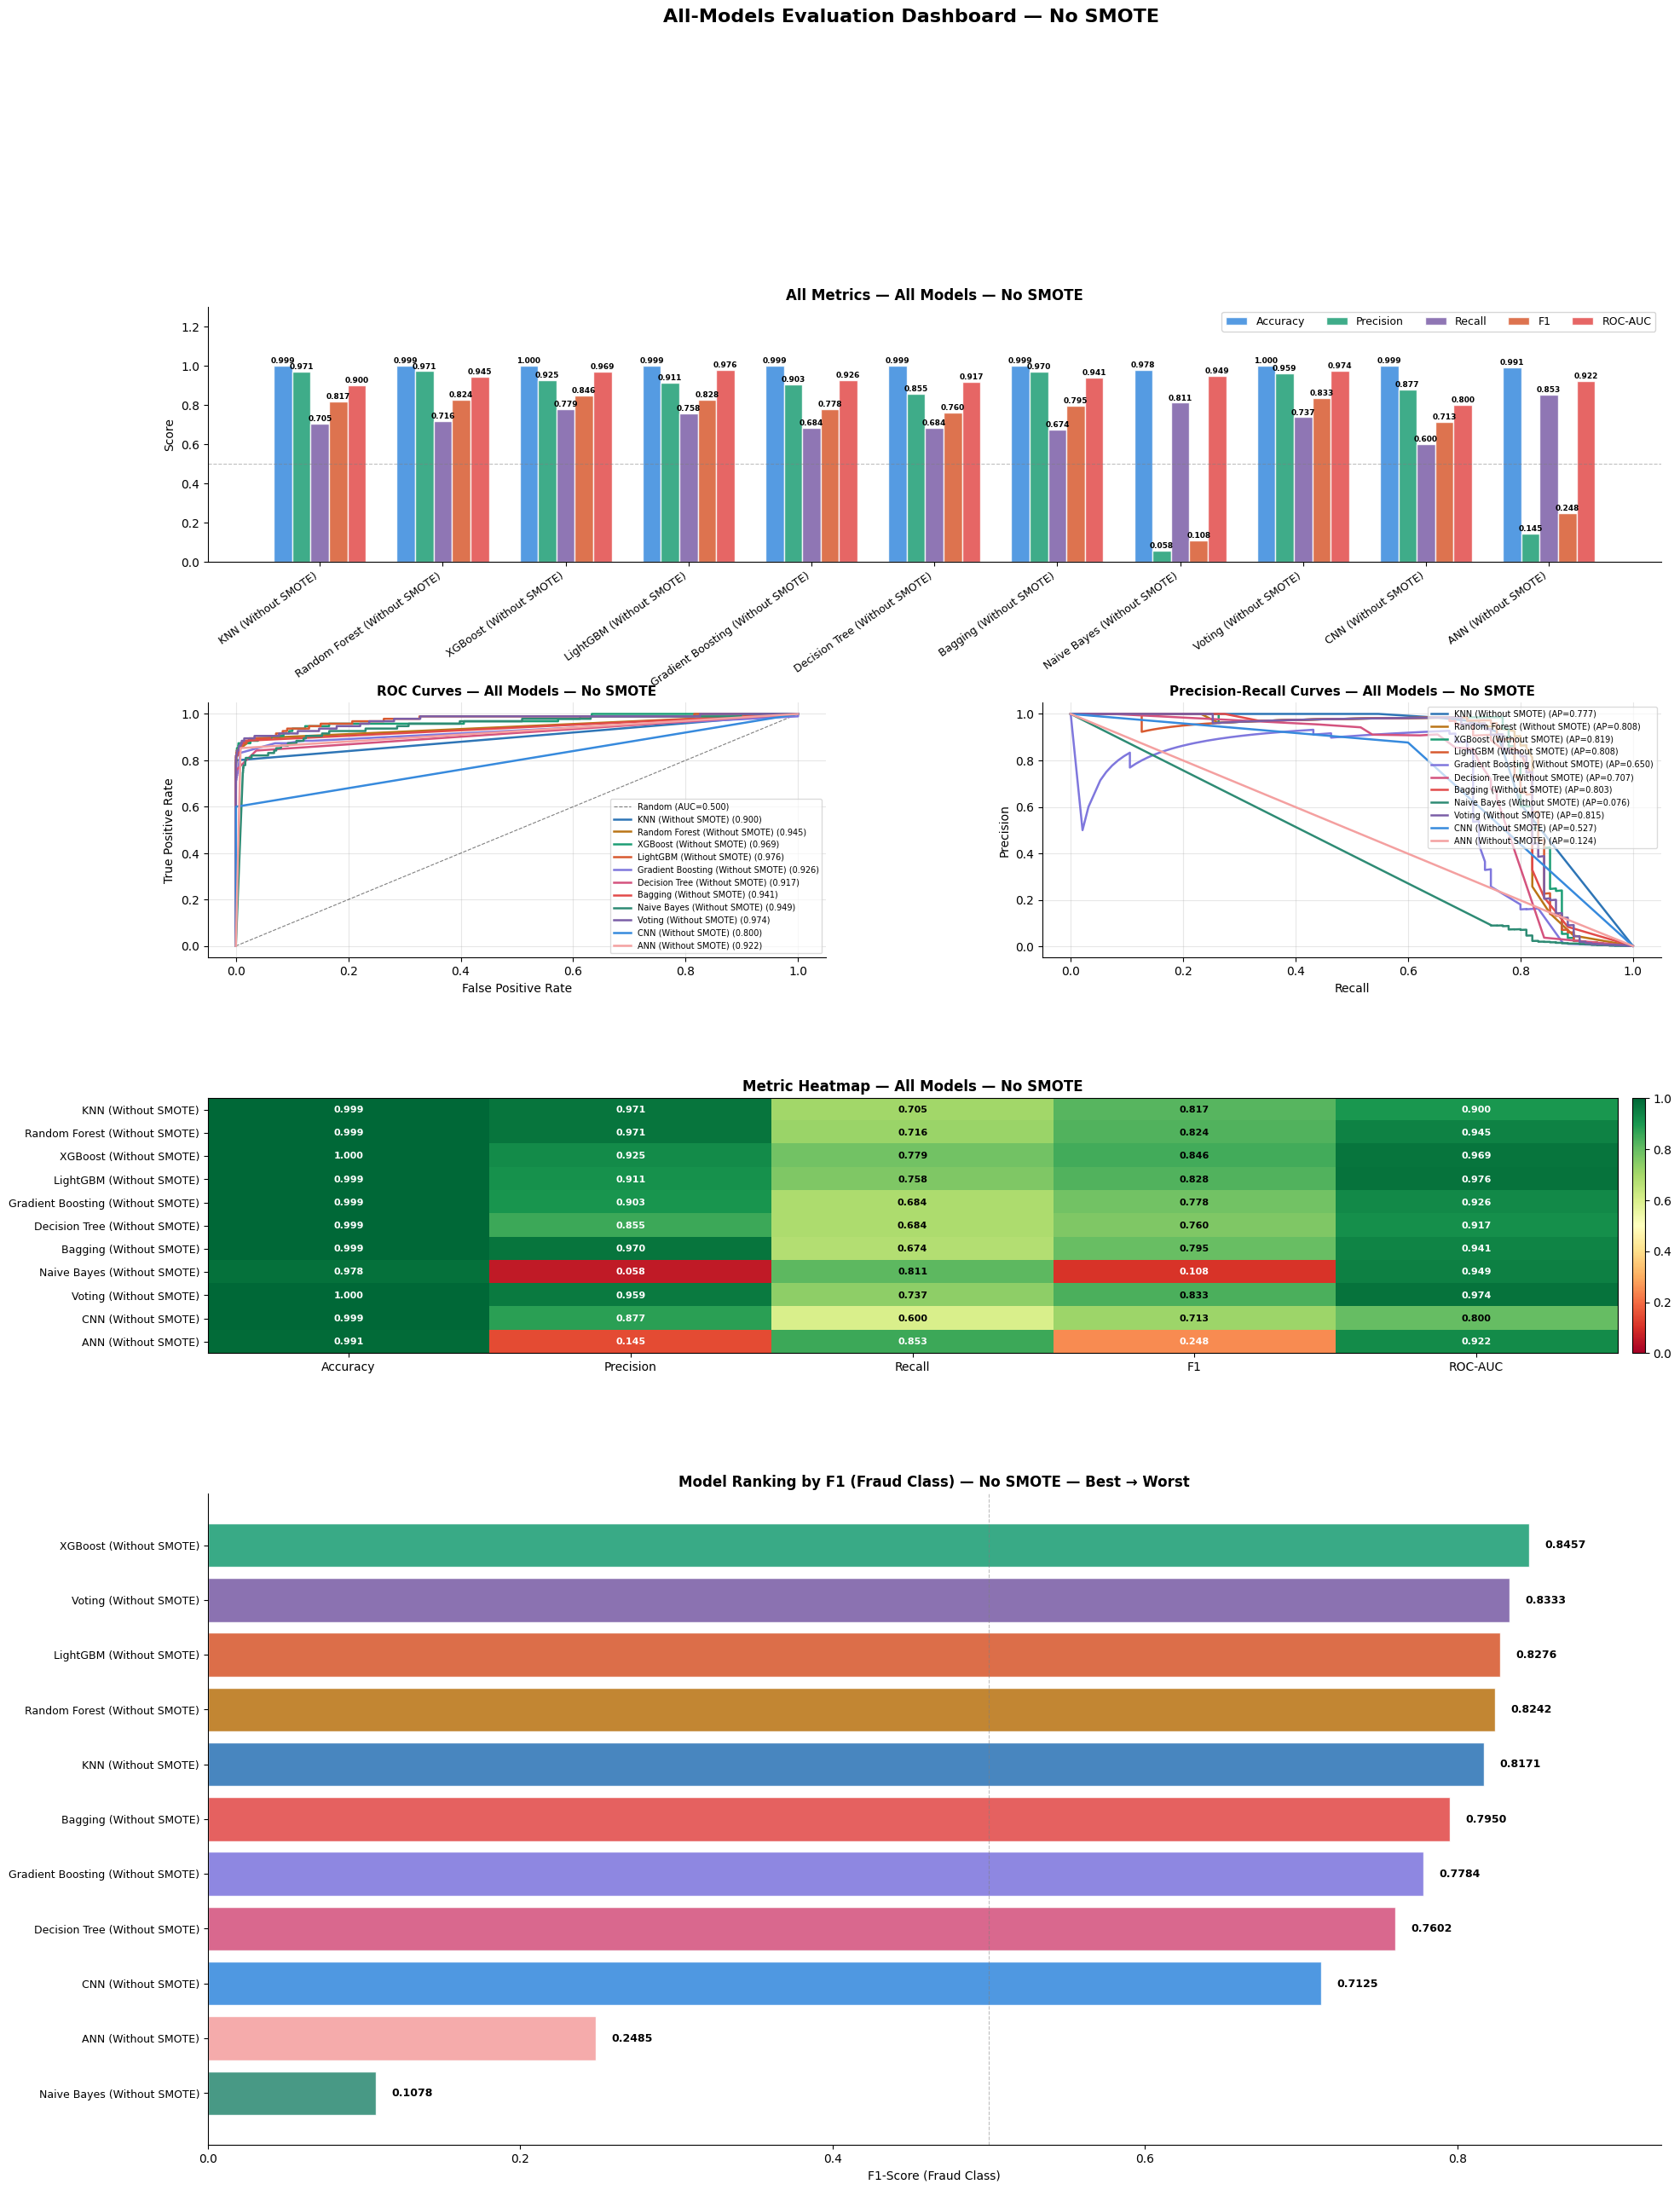

Dashboard saved → all_models_dashboard_No_SMOTE.png


In [34]:
plot_all_models(results_no_smote, y_test, tag="No SMOTE")

## 7. Model Training — With SMOTE

All models retrained on SMOTE-balanced data. Test set unchanged. Parameters identical to Section 6.

In [35]:
results_smote  = []
registry_smote = {}
dl_roc_smote   = {}

### 7.1 KNN + SMOTE


  KNN (With SMOTE)
  Accuracy         : 0.9978
  ROC-AUC          : 0.9151
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0022 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.42      0.82      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.91      0.78     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56542   109]
 [   17    78]]


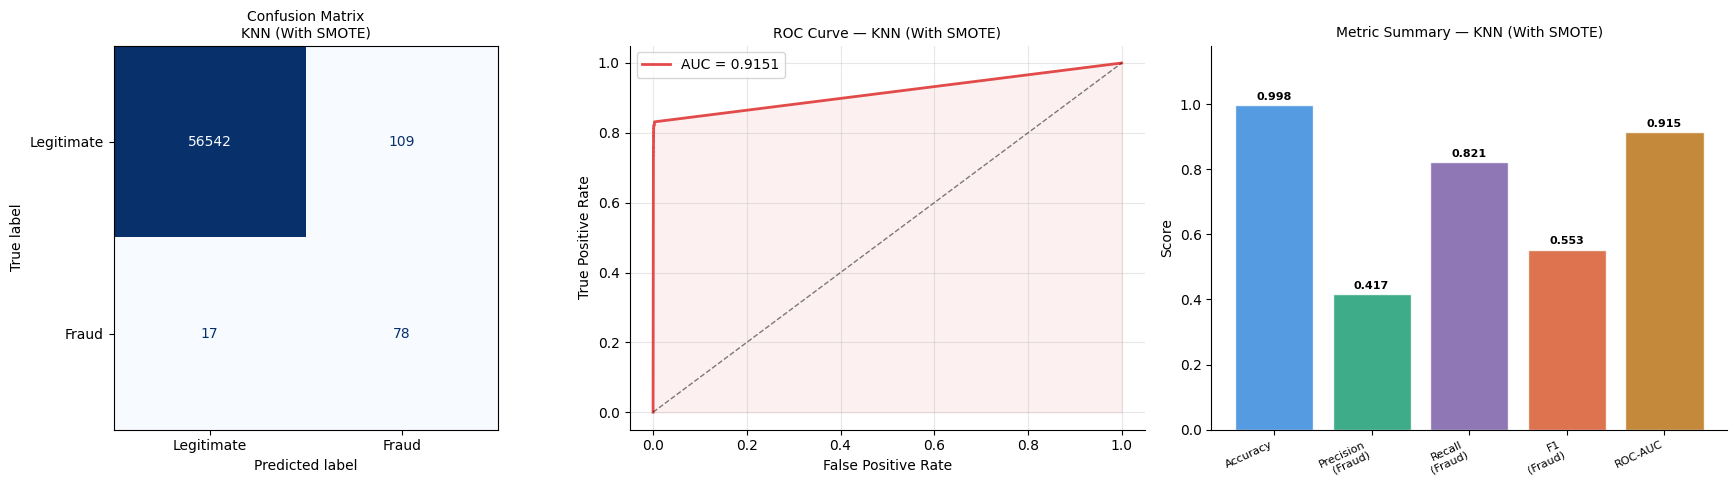

In [36]:
knn_smote = KNeighborsClassifier(n_neighbors=7, weights="distance", metric="minkowski", p=2)
knn_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(knn_smote, X_test_scaled, y_test,
                   model_name="KNN (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["KNN"] = knn_smote

### 7.2 Random Forest + SMOTE


  Random Forest (With SMOTE)
  Accuracy         : 0.9995
  ROC-AUC          : 0.9678
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0005 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56645     6]
 [   23    72]]


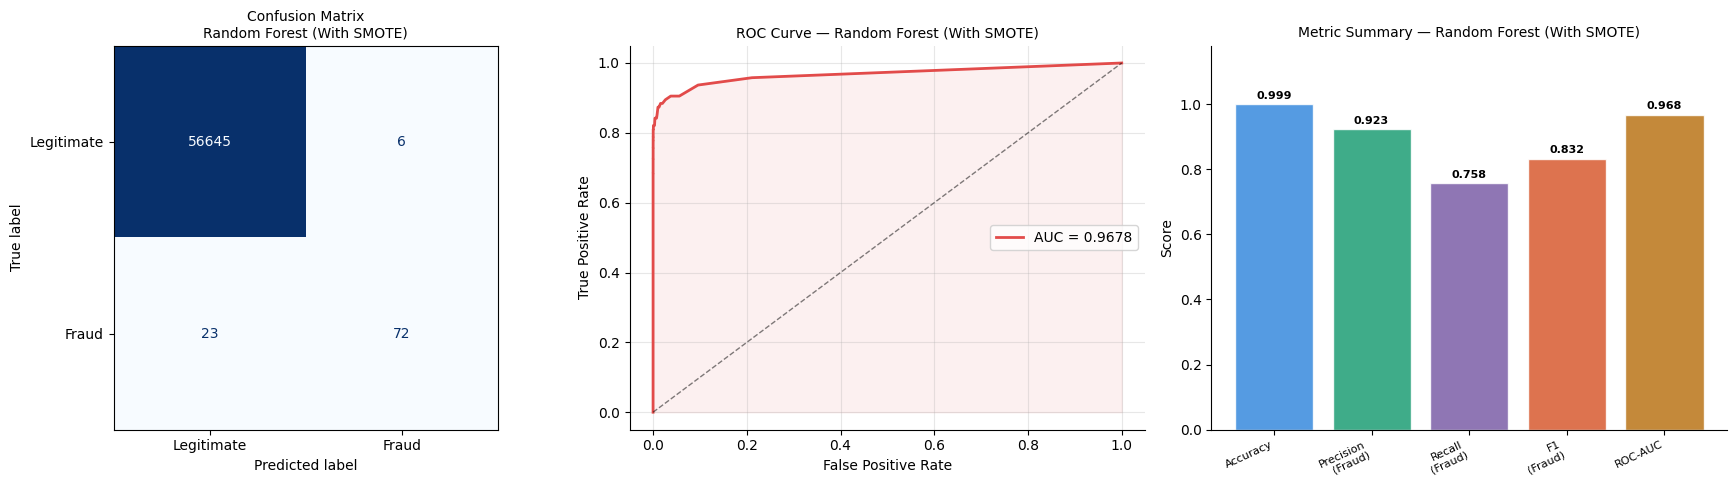

In [37]:
rf_smote = RandomForestClassifier(n_estimators=200, class_weight=None,
                                  random_state=42, n_jobs=-1)
rf_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(rf_smote, X_test_scaled, y_test,
                   model_name="Random Forest (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["Random Forest"] = rf_smote

### 7.3 XGBoost + SMOTE


  XGBoost (With SMOTE)
  Accuracy         : 0.9987
  ROC-AUC          : 0.9740
  Train Accuracy   : 0.9997
  Overfit gap      : 0.0010 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.59      0.81      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56597    54]
 [   18    77]]


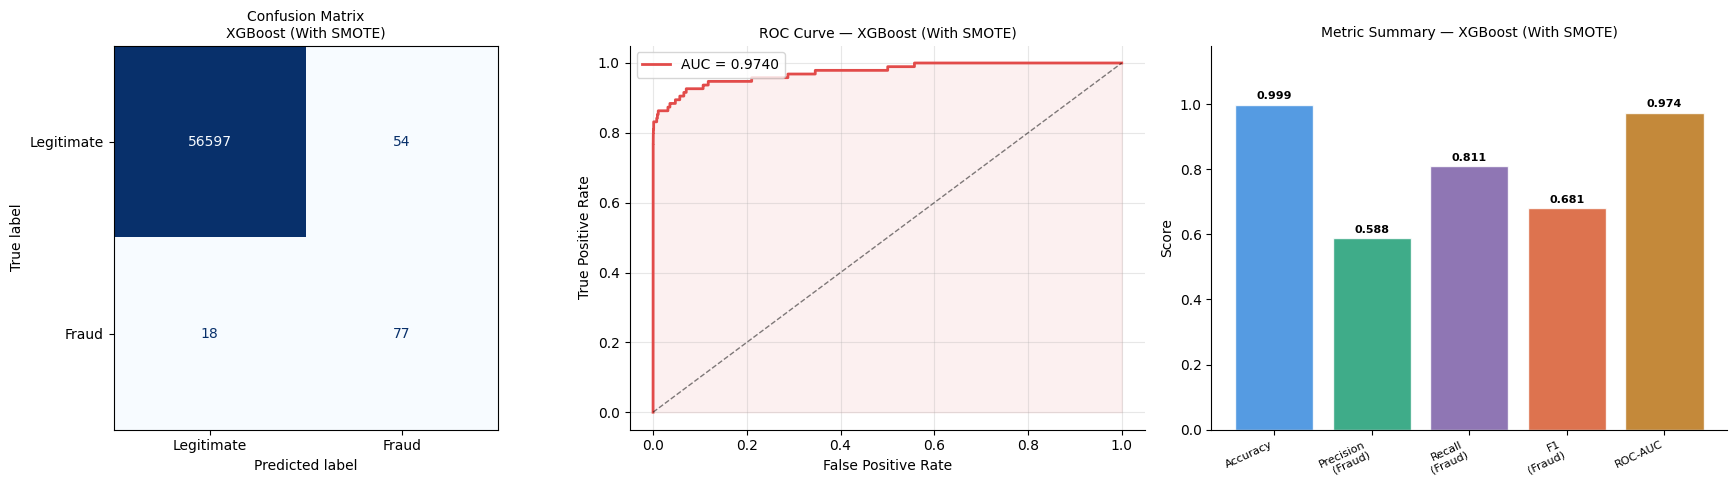

In [38]:
xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=1, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(xgb_smote, X_test_scaled, y_test,
                   model_name="XGBoost (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["XGBoost"] = xgb_smote

### 7.4 LightGBM + SMOTE

[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.144309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

  LightGBM (With SMOTE)
  Accuracy         : 0.9990
  ROC-AUC          : 0.9226
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0010 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.68      0.74      0.71        95

    accuracy                           1.00     56746
   macro avg       0.84      0.87      0.85     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56618    33]
 [   25    70]]


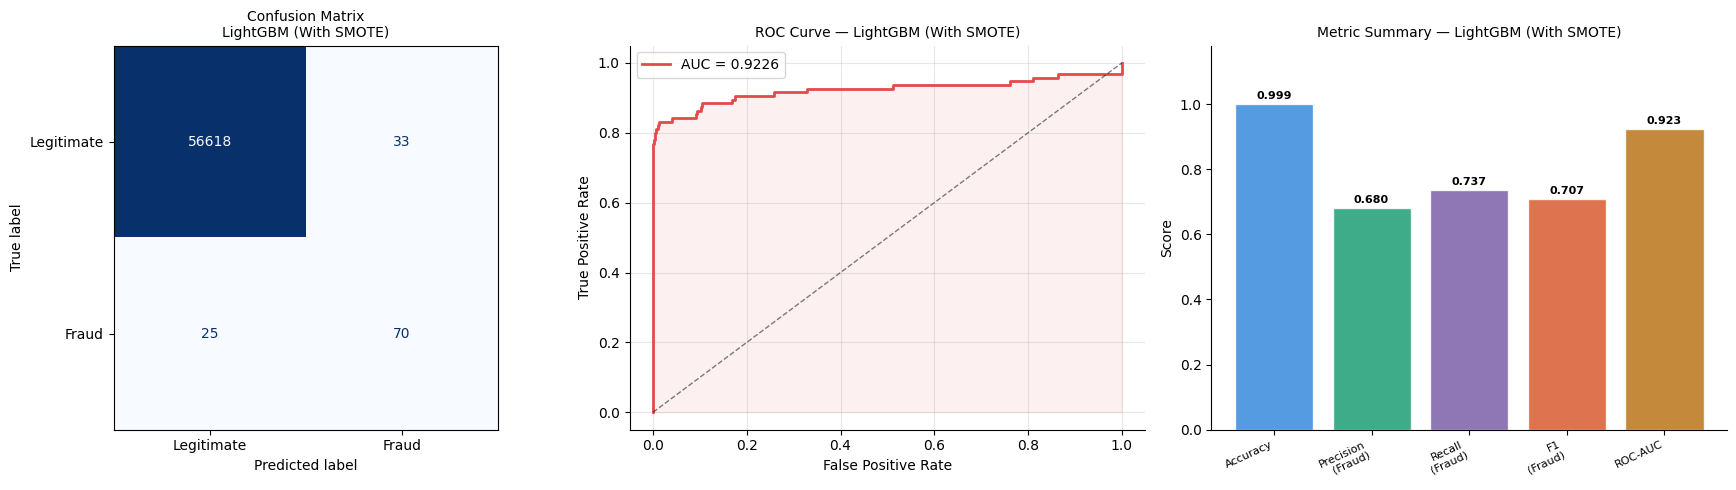

In [39]:
lgbm_smote = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                             class_weight='balanced', random_state=42)
lgbm_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(lgbm_smote, X_test_scaled, y_test,
                   model_name="LightGBM (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["LightGBM"] = lgbm_smote

### 7.5 Gradient Boosting + SMOTE


  Gradient Boosting (With SMOTE)
  Accuracy         : 0.9888
  ROC-AUC          : 0.9769
  Train Accuracy   : 0.9821
  Overfit gap      : -0.0068 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56651
       Fraud       0.11      0.84      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746


Confusion Matrix:
[[56033   618]
 [   15    80]]


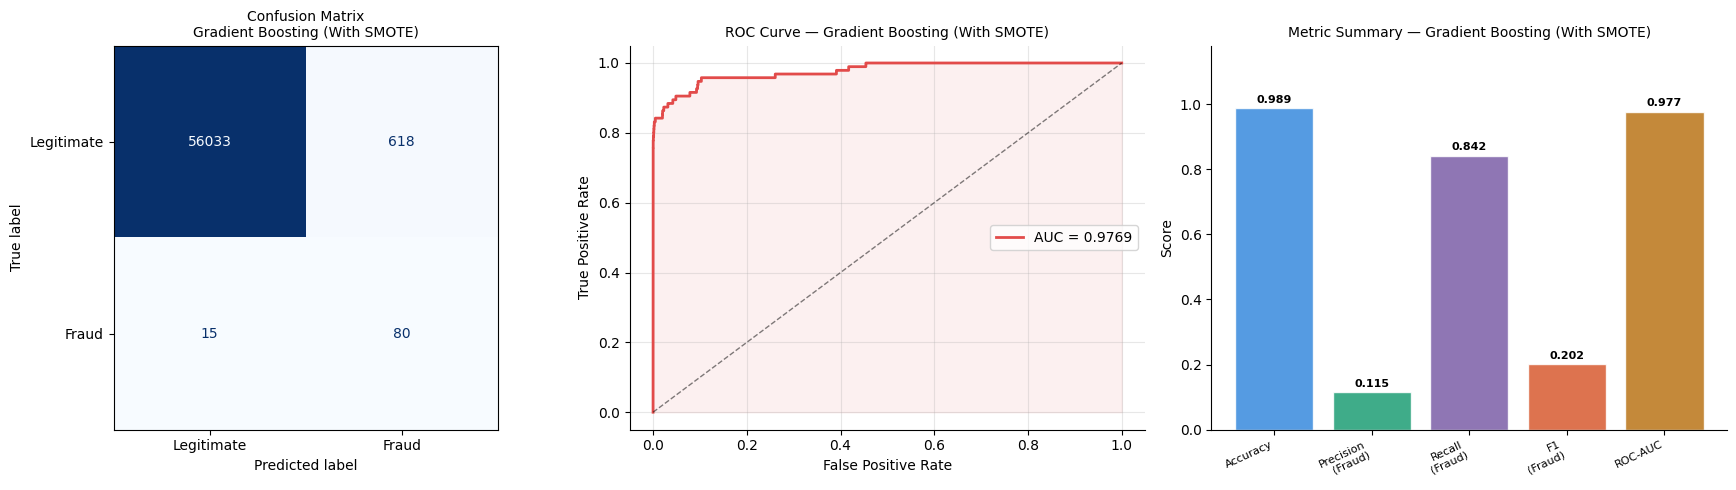

In [40]:
gbm_smote = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                         max_depth=3, random_state=42)
gbm_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(gbm_smote, X_test_scaled, y_test,
                   model_name="Gradient Boosting (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["Gradient Boosting"] = gbm_smote

### 7.6 Decision Tree + SMOTE


  Decision Tree (With SMOTE)
  Accuracy         : 0.9659
  ROC-AUC          : 0.9310
  Train Accuracy   : 0.9676
  Overfit gap      : 0.0017 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98     56651
       Fraud       0.04      0.83      0.08        95

    accuracy                           0.97     56746
   macro avg       0.52      0.90      0.53     56746
weighted avg       1.00      0.97      0.98     56746


Confusion Matrix:
[[54733  1918]
 [   16    79]]


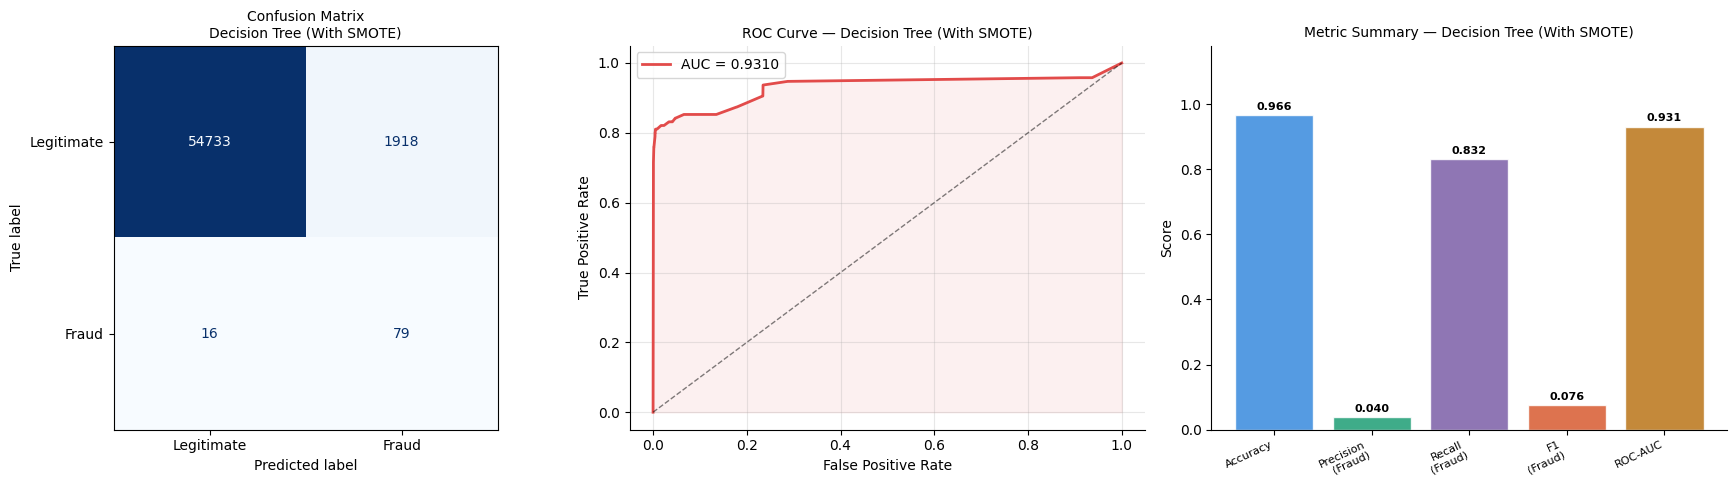

In [41]:
dt_smote = DecisionTreeClassifier(criterion="gini", max_depth=6,
                                   min_samples_split=50, min_samples_leaf=20, random_state=42)
dt_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(dt_smote, X_test_scaled, y_test,
                   model_name="Decision Tree (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["Decision Tree"] = dt_smote

### 7.7 Bagging + SMOTE


  Bagging (With SMOTE)
  Accuracy         : 0.9990
  ROC-AUC          : 0.9142
  Train Accuracy   : 1.0000
  Overfit gap      : 0.0010 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.68      0.73      0.70        95

    accuracy                           1.00     56746
   macro avg       0.84      0.86      0.85     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56618    33]
 [   26    69]]


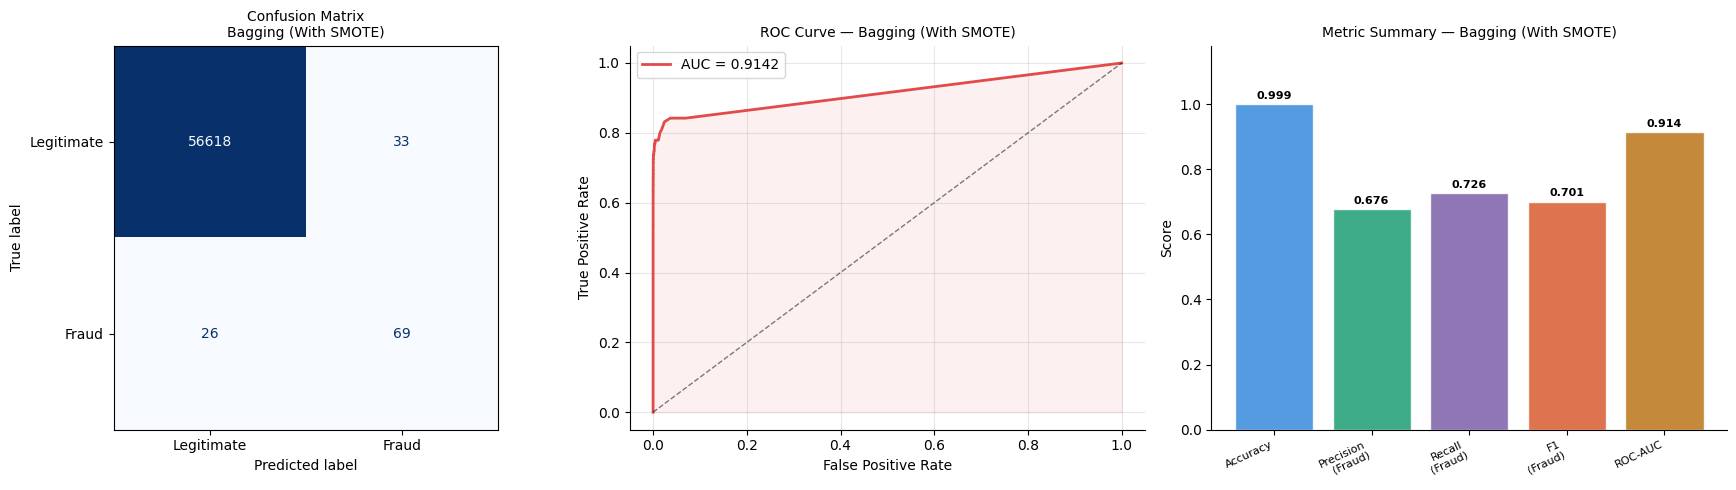

In [42]:
bagging_smote = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    n_estimators=100, random_state=42, n_jobs=-1)
bagging_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(bagging_smote, X_test_scaled, y_test,
                   model_name="Bagging (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["Bagging"] = bagging_smote

### 7.8 Naive Bayes + SMOTE


  Naive Bayes (With SMOTE)
  Accuracy         : 0.9759
  ROC-AUC          : 0.9448
  Train Accuracy   : 0.9173
  Overfit gap      : -0.0586 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.05      0.81      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.54     56746
weighted avg       1.00      0.98      0.99     56746


Confusion Matrix:
[[55302  1349]
 [   18    77]]


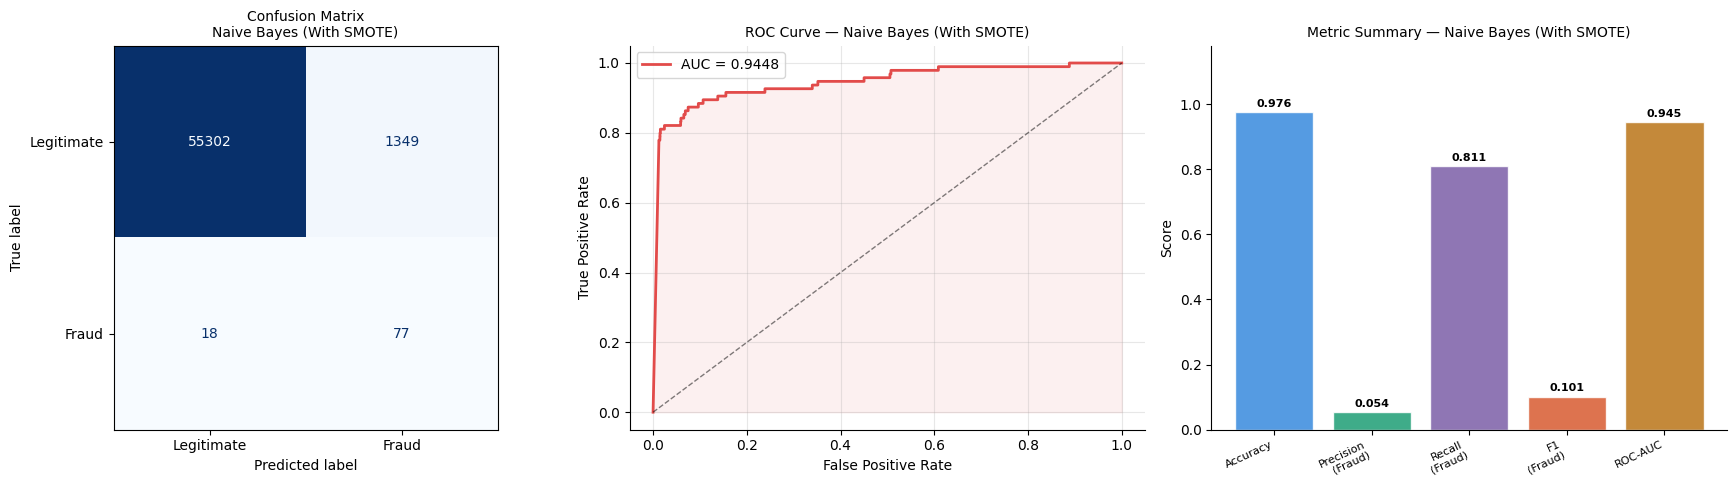

In [43]:
nb_smote = GaussianNB()
nb_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(nb_smote, X_test_scaled, y_test,
                   model_name="Naive Bayes (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["Naive Bayes"] = nb_smote

### 7.9 Voting Classifier + SMOTE


  Voting (With SMOTE)
  Accuracy         : 0.9990
  ROC-AUC          : 0.9775
  Train Accuracy   : 0.9998
  Overfit gap      : 0.0008 healthy

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.66      0.81      0.73        95

    accuracy                           1.00     56746
   macro avg       0.83      0.90      0.86     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56611    40]
 [   18    77]]


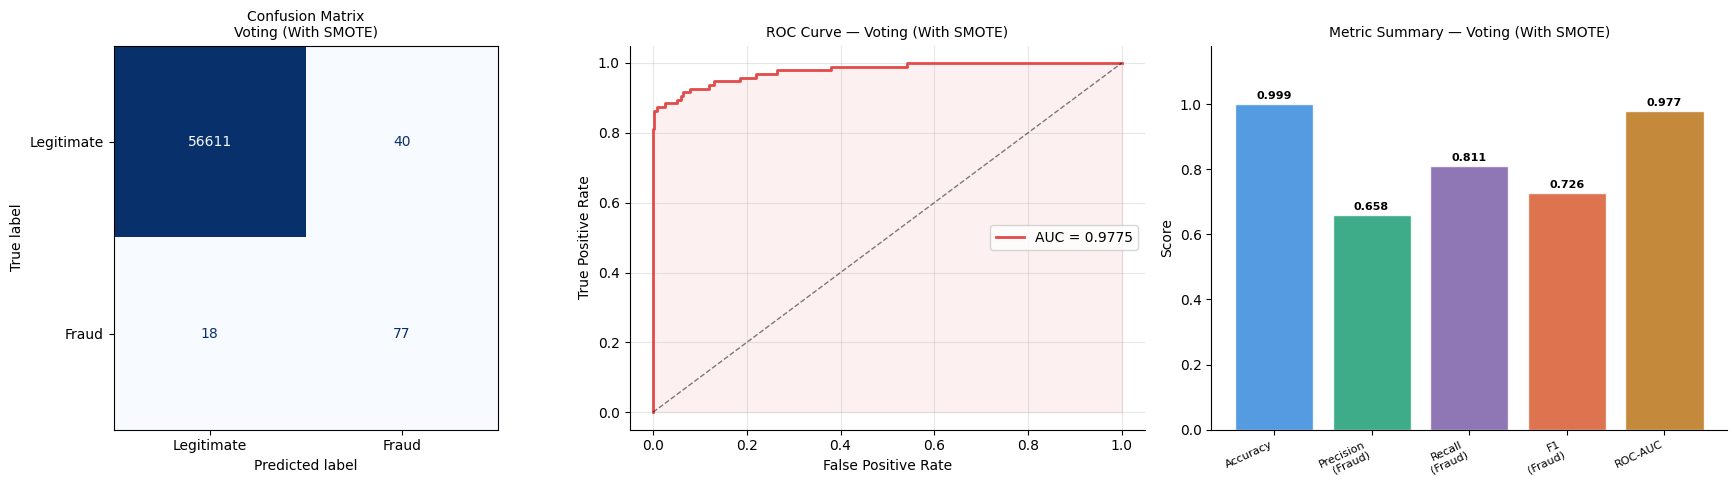

In [44]:
from sklearn.linear_model import LogisticRegression

rf_vs  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
knn_vs = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
lr_vs  = LogisticRegression(max_iter=1000)
xgb_vs = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                        eval_metric='logloss', random_state=42)

voting_smote = VotingClassifier(
    estimators=[('rf', rf_vs), ('knn', knn_vs), ('lr', lr_vs), ('xgb', xgb_vs)],
    voting='soft')
voting_smote.fit(X_train_resampled, y_train_resampled)
r = evaluate_model(voting_smote, X_test_scaled, y_test,
                   model_name="Voting (With SMOTE)",
                   X_train=X_train_resampled, y_train=y_train_resampled)
results_smote.append(r)
registry_smote["Voting"] = voting_smote

### 7.10 CNN + SMOTE

In [45]:
X_train_cnn_sm = X_train_resampled.values.reshape(X_train_resampled.shape[0], X_train_resampled.shape[1], 1)

cnn_smote = Sequential([
    Conv1D(32, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn_sm.shape[1], 1)),
    BatchNormalization(), MaxPooling1D(2),
    Conv1D(64, kernel_size=3, activation='relu'),
    BatchNormalization(), MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'), Dropout(0.4),
    Dense(1, activation='sigmoid')
])
cnn_smote.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])

history_cnn_sm = cnn_smote.fit(
    X_train_cnn_sm, y_train_resampled,
    epochs=20, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1)

Epoch 1/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.9893 - loss: 0.0317 - val_accuracy: 0.9994 - val_loss: 0.0051
Epoch 2/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 5.6540e-04
Epoch 3/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9983 - loss: 0.0062 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 4/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 0.9998 - val_loss: 0.0014
Epoch 5/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9988 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 3.9824e-04
Epoch 6/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 6.1070e-04
Epoch 7/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 6.3708e-04
Epoch 8/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - ac

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

  CNN (With SMOTE)
  Accuracy         : 0.9988
  ROC-AUC          : 0.8891

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.62      0.78      0.69        95

    accuracy                           1.00     56746
   macro avg       0.81      0.89      0.85     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56606    45]
 [   21    74]]


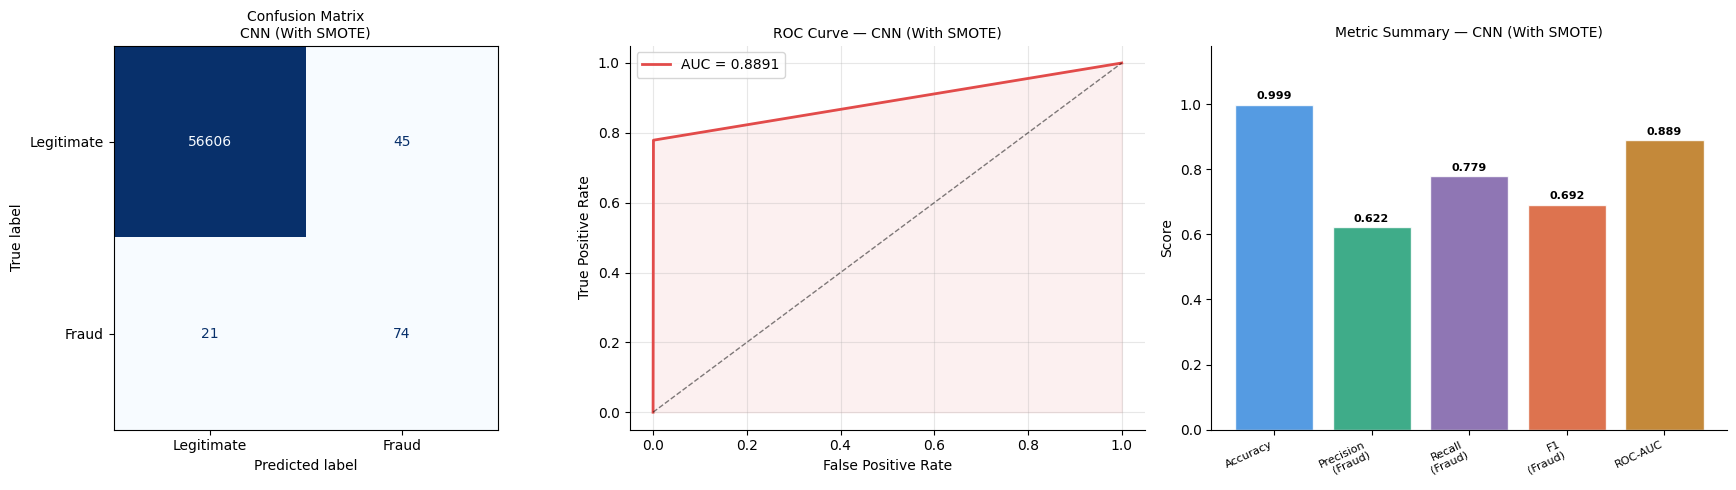

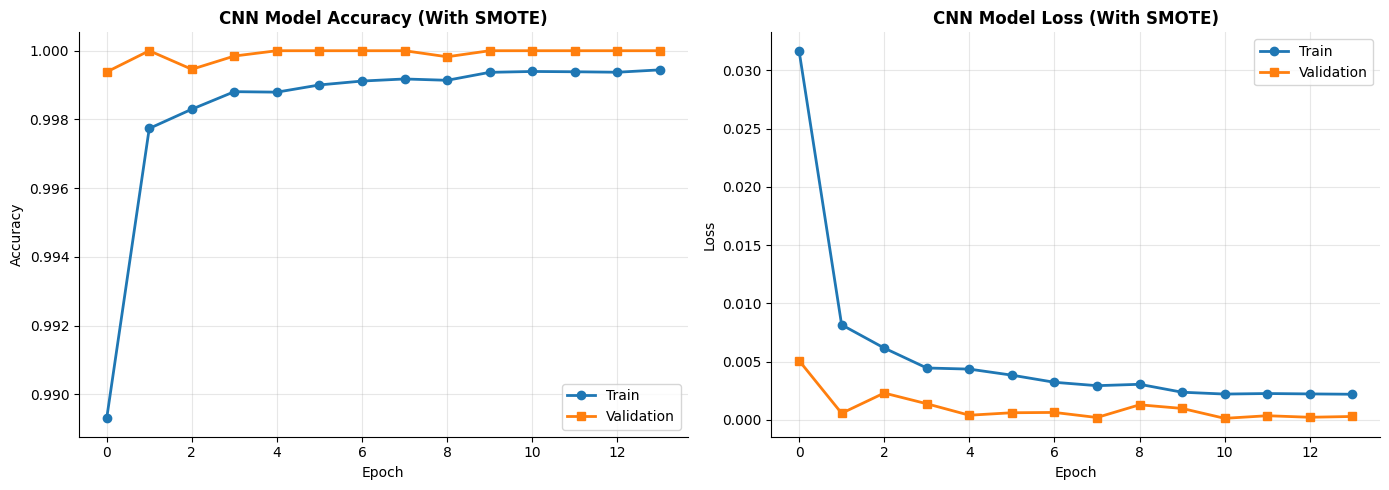

In [46]:
y_prob_cnn_sm = cnn_smote.predict(X_test_cnn).ravel()
y_pred_cnn_sm = (y_prob_cnn_sm > 0.5).astype(int)
y_proba_cnn_sm = cnn_smote.predict(X_test_cnn).ravel()
s_cnn = evaluate_model(
    model       = cnn_smote,
    X_test      = X_test_cnn,
    y_test      = y_test,
    model_name  = "CNN (With SMOTE)",
)
results_smote.append(s_cnn)
registry_smote["CNN"] = cnn_smote

if hasattr(cnn_smote, 'history') and cnn_smote.history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_cnn_sm.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(history_cnn_sm.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title('CNN Model Accuracy (With SMOTE)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    axes[1].plot(history_cnn_sm.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(history_cnn_sm.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title('CNN Model Loss (With SMOTE)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

### 7.11 ANN + SMOTE

In [47]:
ann_smote = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann_smote.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])

history_ann_sm = ann_smote.fit(
    X_train_resampled.values, y_train_resampled,
    epochs=20, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1)

Epoch 1/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9720 - loss: 0.0757 - val_accuracy: 0.9953 - val_loss: 0.0169
Epoch 2/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9927 - loss: 0.0220 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 3/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9958 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 4/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9969 - loss: 0.0112 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9977 - loss: 0.0094 - val_accuracy: 0.9998 - val_loss: 0.0020
Epoch 6/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9978 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 7.9132e-04
Epoch 7/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9982 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9982 - loss: 0.007

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

  ANN (With SMOTE)
  Accuracy         : 0.9989
  ROC-AUC          : 0.9101

Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.64      0.82      0.72        95

    accuracy                           1.00     56746
   macro avg       0.82      0.91      0.86     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56607    44]
 [   17    78]]


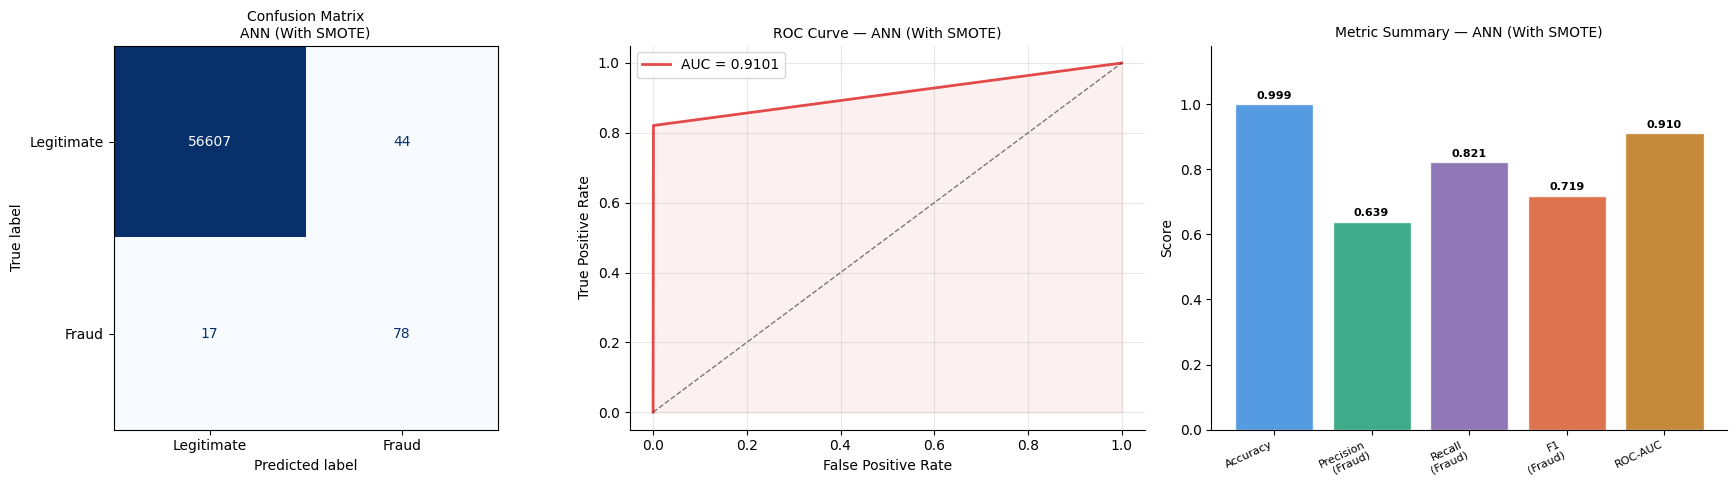

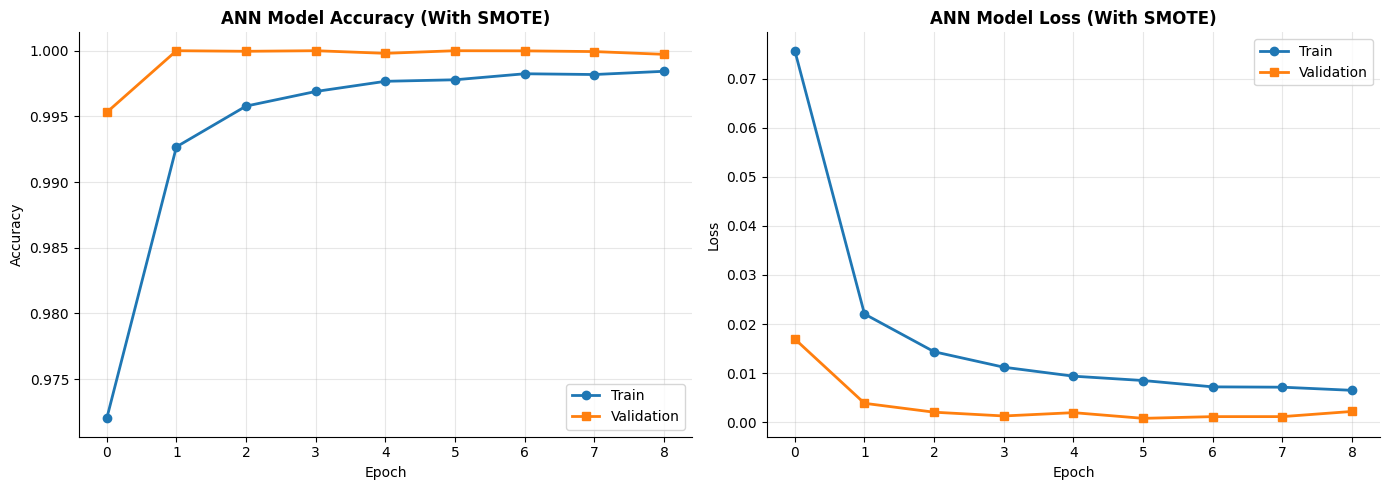

In [48]:
y_prob_ann_sm = ann_smote.predict(X_test_scaled.values).ravel()
y_pred_ann_sm = (y_prob_ann_sm > 0.5).astype(int)
y_proba_ann_sm = ann_smote.predict(X_test_scaled.values).ravel()
s_ann = evaluate_model(
    model       = ann_smote,
    X_test      = X_test_scaled.values,
    y_test      = y_test,
    model_name  = "ANN (With SMOTE)",
)
results_smote.append(s_ann)
registry_smote["ANN"] = ann_smote

if hasattr(ann_smote, 'history') and ann_smote.history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_ann_sm.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(history_ann_sm.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title('ANN Model Accuracy (With SMOTE)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    axes[1].plot(history_ann_sm.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(history_ann_sm.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title('ANN Model Loss (With SMOTE)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

### 7.12 Dashboard — All models (With SMOTE)

In [49]:
df_smote = pd.DataFrame(results_smote).set_index('Model')

# Identify columns that should not be styled/formatted as numeric metrics
non_metric_cols = ['_y_proba', '_y_pred']

# Create a display-ready DataFrame by dropping non-metric columns
df_smote_display = df_smote.drop(columns=[col for col in non_metric_cols if col in df_smote.columns])

print("\n All Models — With SMOTE")
display(df_smote_display.style.apply(style_results_cls)
        .format({c: '{:.4f}' for c in df_smote_display.columns})
        .set_caption("Credit Card Fraud — SMOTE Results"))


 All Models — With SMOTE


,Accuracy,Precision,Recall,F1,F1 (wtd),ROC-AUC
Model,,,,,,
KNN (With SMOTE),0.9978,0.4171,0.8211,0.5532,0.9981,0.9151
Random Forest (With SMOTE),0.9995,0.9231,0.7579,0.8324,0.9995,0.9678
XGBoost (With SMOTE),0.9987,0.5878,0.8105,0.6814,0.9988,0.9740
LightGBM (With SMOTE),0.9990,0.6796,0.7368,0.7071,0.9990,0.9226
Gradient Boosting (With SMOTE),0.9888,0.1146,0.8421,0.2018,0.9931,0.9769
Decision Tree (With SMOTE),0.9659,0.0396,0.8316,0.0755,0.9811,0.9310
Bagging (With SMOTE),0.9990,0.6765,0.7263,0.7005,0.9990,0.9142
Naive Bayes (With SMOTE),0.9759,0.0540,0.8105,0.1012,0.9863,0.9448
Voting (With SMOTE),0.9990,0.6581,0.8105,0.7264,0.9990,0.9775



DEBUG: SMOTE - F1 Values Check
KNN (With SMOTE): F1 = 0.5532
Random Forest (With SMOTE): F1 = 0.8324
XGBoost (With SMOTE): F1 = 0.6814
LightGBM (With SMOTE): F1 = 0.7071
Gradient Boosting (With SMOTE): F1 = 0.2018
Decision Tree (With SMOTE): F1 = 0.0755
Bagging (With SMOTE): F1 = 0.7005
Naive Bayes (With SMOTE): F1 = 0.1012
Voting (With SMOTE): F1 = 0.7264
CNN (With SMOTE): F1 = 0.6916
ANN (With SMOTE): F1 = 0.7189



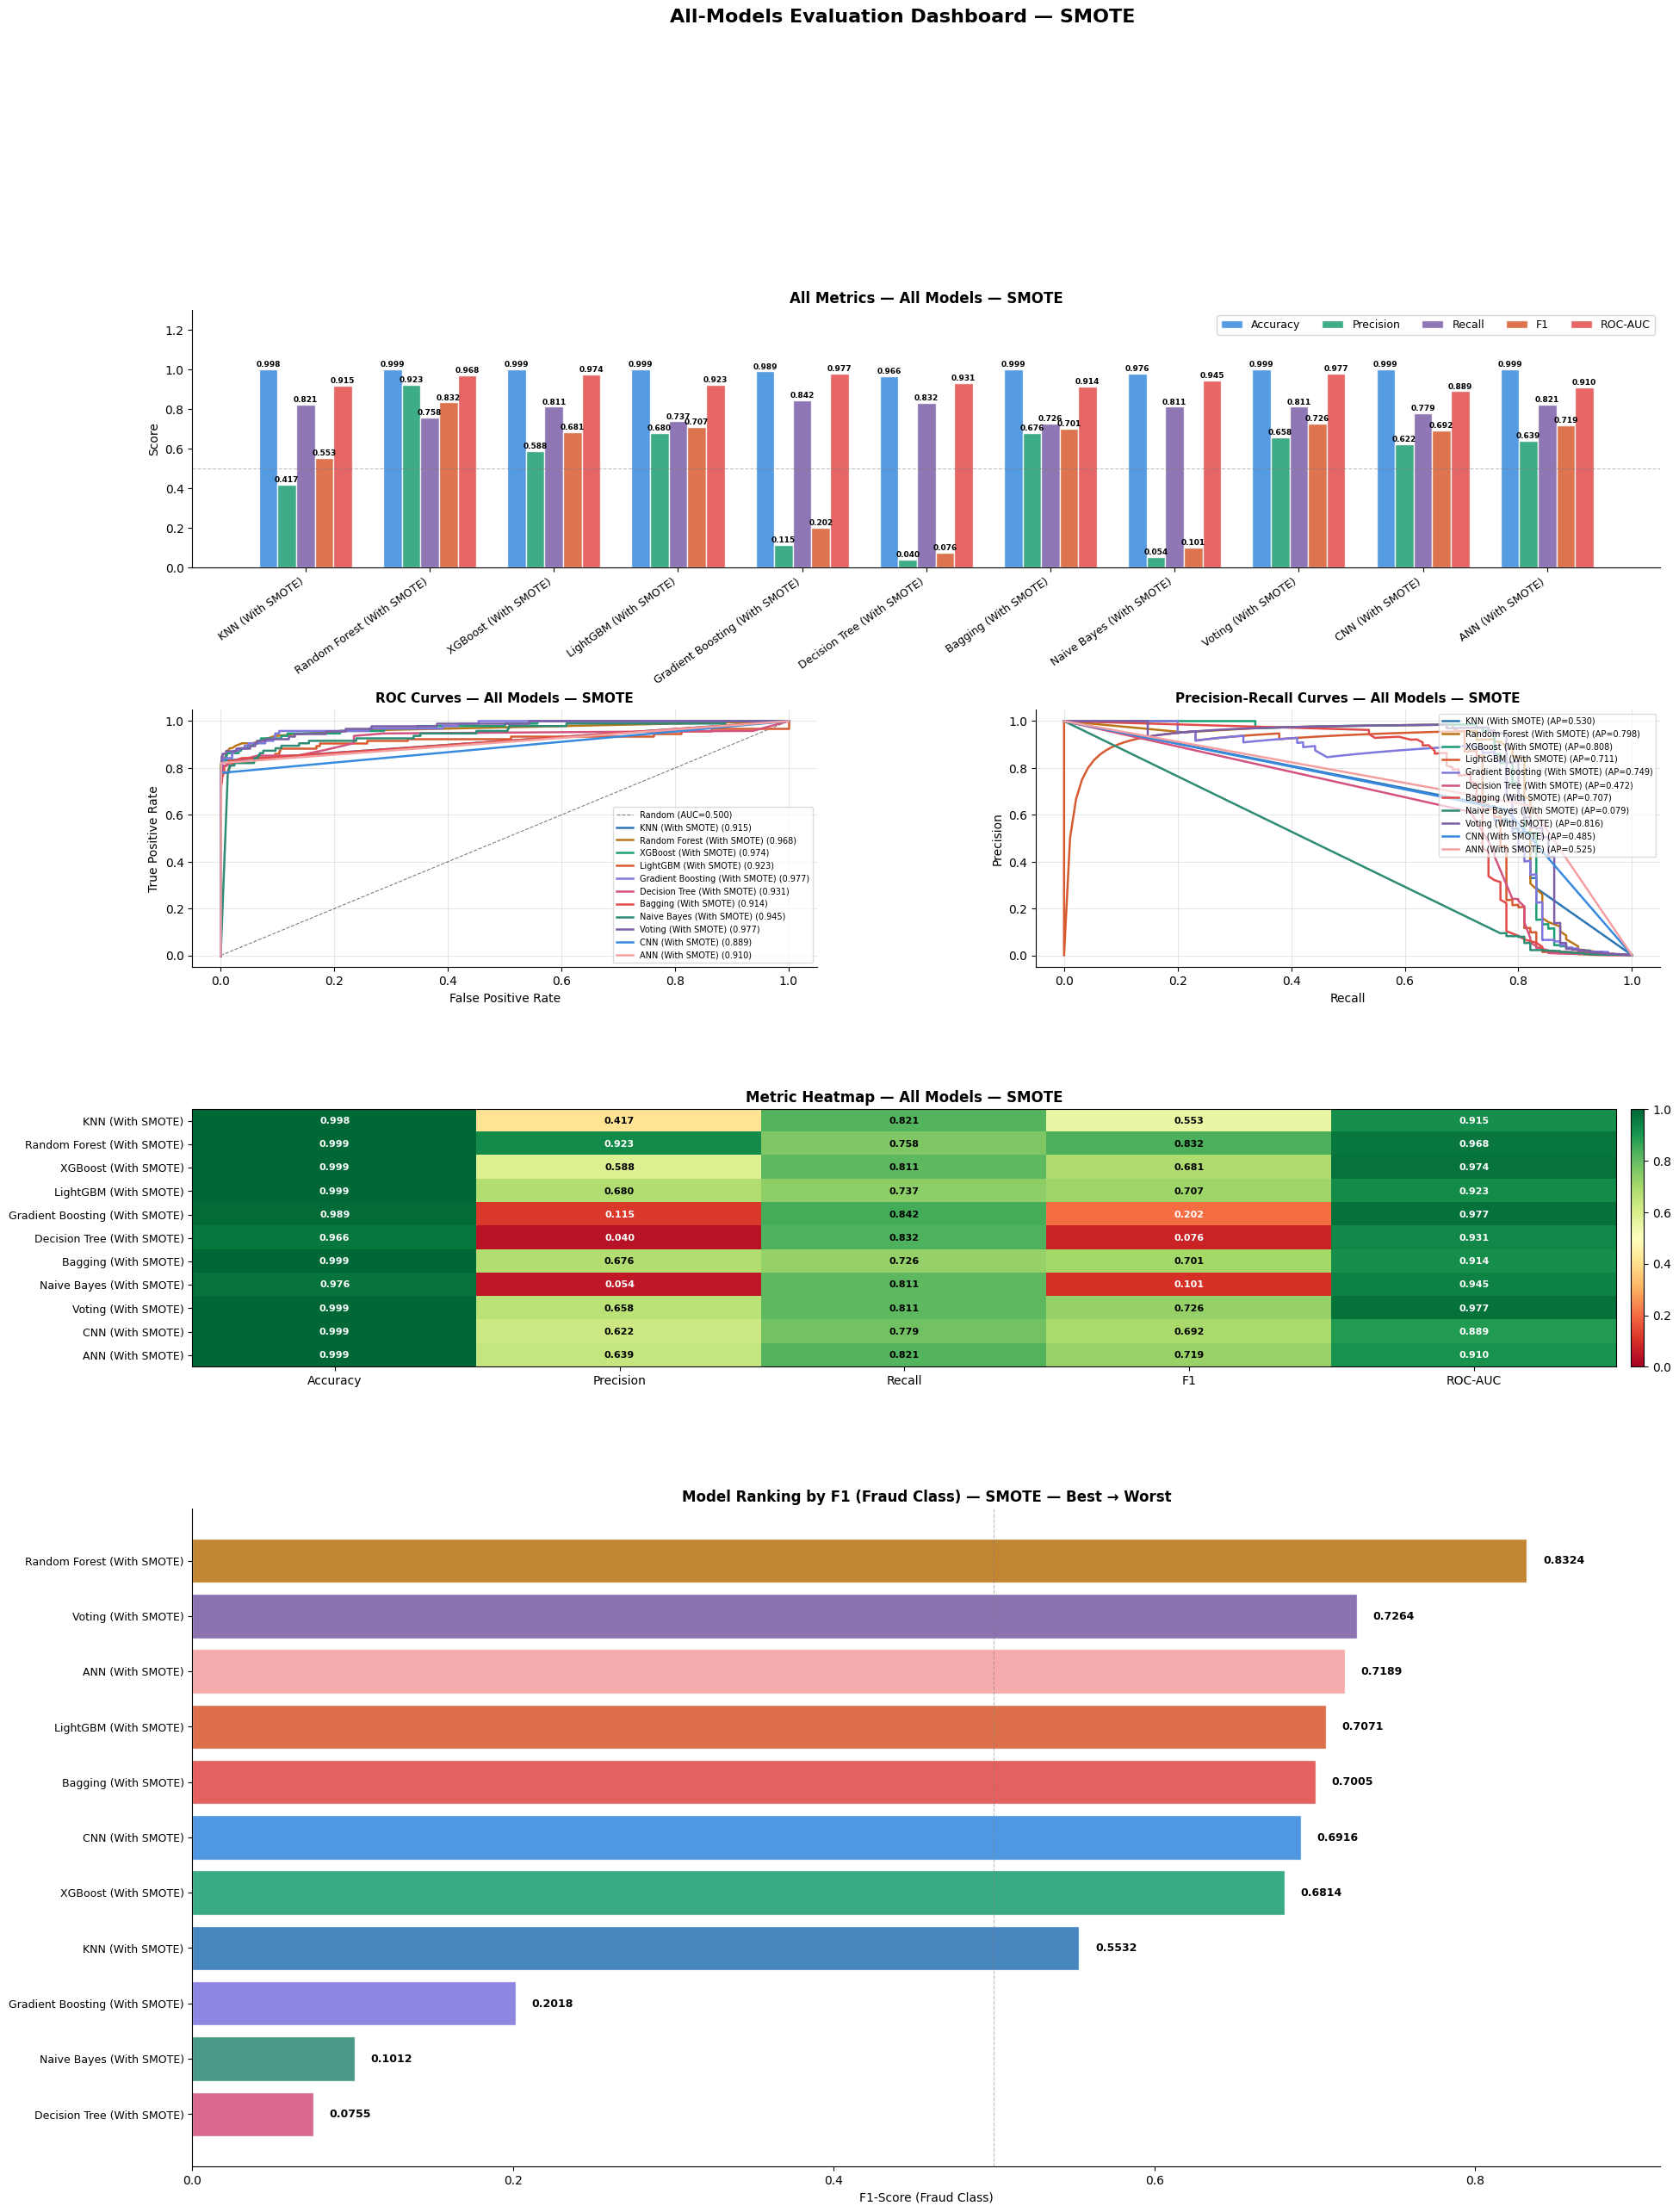

Dashboard saved → all_models_dashboard_SMOTE.png


In [50]:
# ── Call AFTER all 11 SMOTE models have run ─────────────────────────
# Generates the full evaluation dashboard for the SMOTE condition.
plot_all_models(results_smote, y_test, tag="SMOTE")

## 8. Model Comparison Bar Charts

Original summary bar charts from file 1 — unchanged.

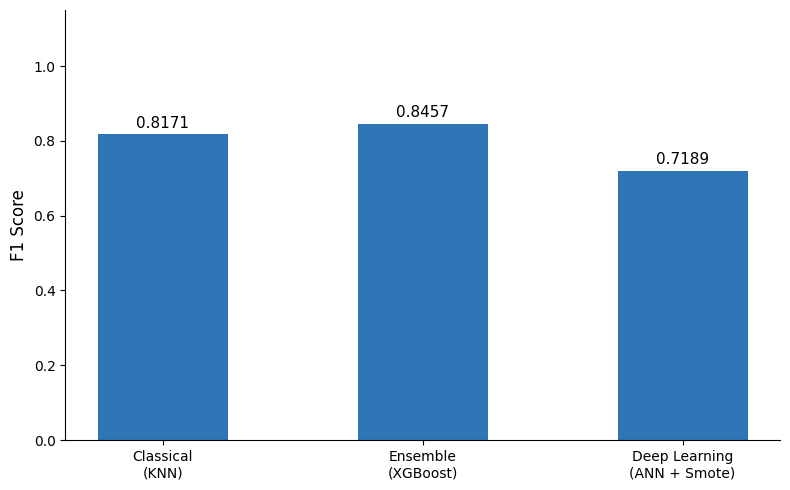

In [75]:
# -- Chart 1: Best-of-category F1 (No SMOTE) ----------------------------------
def get_f1(results, keyword):
    """Return F1 of first result whose Model name contains keyword."""
    for r in results:
        if keyword.lower() in r['Model'].lower():
            return round(r['F1'], 4)
    return 0.0

classical_f1  = get_f1(results_no_smote, 'KNN')
ensemble_f1   = get_f1(results_no_smote, 'XGBoost')
dl_f1         = get_f1(results_smote, 'ANN')

models    = ['Classical\n(KNN)', 'Ensemble\n(XGBoost)', 'Deep Learning\n(ANN + Smote)']
f1_scores = [classical_f1, ensemble_f1, dl_f1]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, f1_scores, color='#2E75B6', width=0.5)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, color='black')
ax.set_ylabel('F1 Score', fontsize=12)

ax.set_ylim(0, 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()


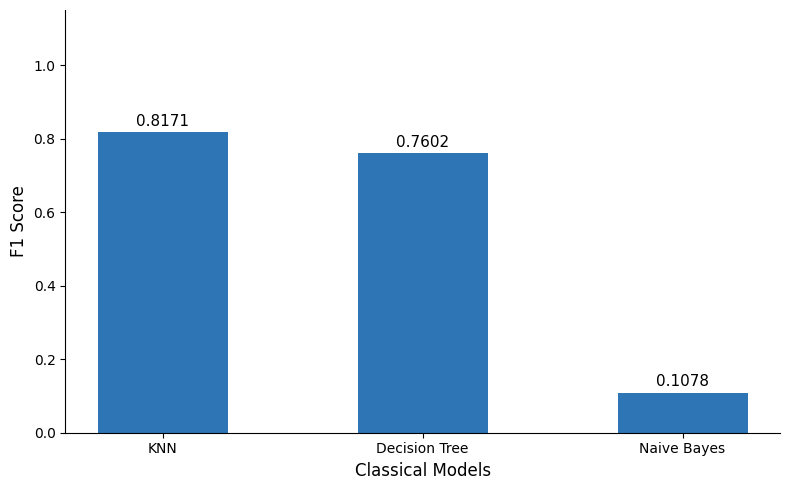

In [70]:
# -- Chart 2: Classical Models F1 (No SMOTE) ----------------------------------
classical_keys = ['KNN', 'Decision Tree', 'Naive Bayes']
classical_labels = ['KNN', 'Decision Tree', 'Naive Bayes']

no_smote_dict = {r['Model']: r['F1'] for r in results_no_smote}

f1_scores = [
    round(next((v for k, v in no_smote_dict.items() if key in k), 0.0), 4)
    for key in classical_keys
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(classical_labels, f1_scores, color='#2E75B6', width=0.5)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, color='black')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('Classical Models', fontsize=12)
ax.set_ylim(0, 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()


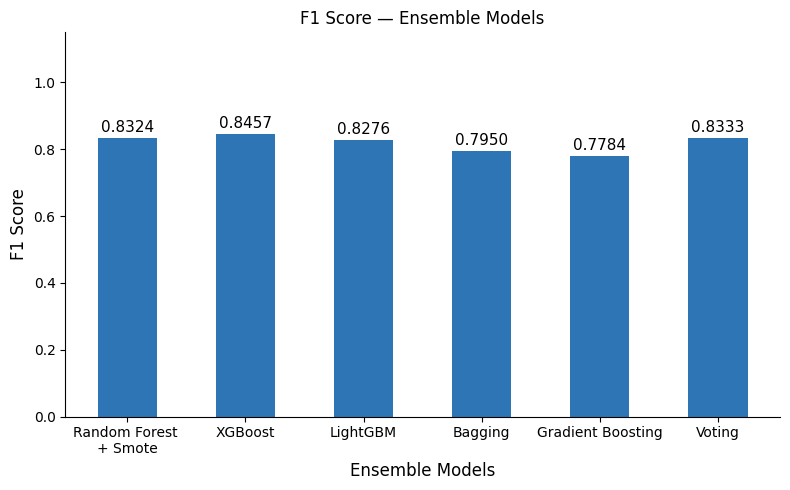

In [66]:
# -- Chart 3: Ensemble Models F1 (No SMOTE) -----------------------------------
ensemble_keys   = ['Random Forest', 'XGBoost', 'LightGBM', 'Bagging', 'Gradient Boosting', 'Voting']
ensemble_labels = ['Random Forest \n+ Smote', 'XGBoost', 'LightGBM', 'Bagging', 'Gradient Boosting', 'Voting']

no_smote_dict = {r['Model']: r['F1'] for r in results_no_smote}
smote_dict     = {r['Model']: r['F1'] for r in results_smote}

f1_scores = [
    round(next((v for k, v in smote_dict.items()    if 'Random Forest' in k), 0.0), 4),
    round(next((v for k, v in no_smote_dict.items() if 'XGBoost'           in k), 0.0), 4),
    round(next((v for k, v in no_smote_dict.items() if 'LightGBM'          in k), 0.0), 4),
    round(next((v for k, v in no_smote_dict.items() if 'Bagging'           in k), 0.0), 4),
    round(next((v for k, v in no_smote_dict.items() if 'Gradient Boosting' in k), 0.0), 4),
    round(next((v for k, v in no_smote_dict.items() if 'Voting'            in k), 0.0), 4),
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ensemble_labels, f1_scores, color='#2E75B6', width=0.5)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, color='black')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('Ensemble Models', fontsize=12)
ax.set_title('F1 Score — Ensemble Models', fontsize=12)
ax.set_ylim(0, 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()


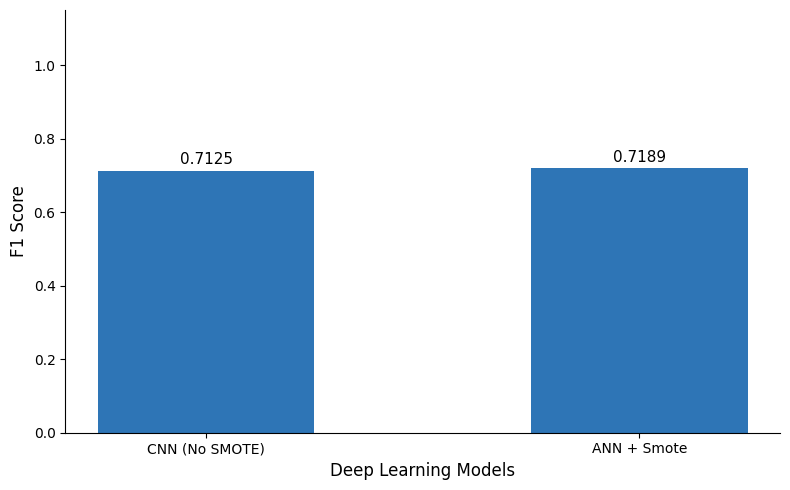

In [74]:
# -- Chart 4: Deep Learning Models F1 -----------------------------------------
no_smote_dict = {r['Model']: r['F1'] for r in results_no_smote}
smote_dict    = {r['Model']: r['F1'] for r in results_smote}

cnn_f1 = round(next((v for k, v in no_smote_dict.items() if 'CNN' in k), 0.0), 4)
ann_f1 = round(next((v for k, v in smote_dict.items()    if 'ANN' in k), 0.0), 4)

models    = ['CNN (No SMOTE)', 'ANN + Smote']
f1_scores = [cnn_f1, ann_f1]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, f1_scores, color='#2E75B6', width=0.5)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, color='black')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('Deep Learning Models', fontsize=12)
ax.set_ylim(0, 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()


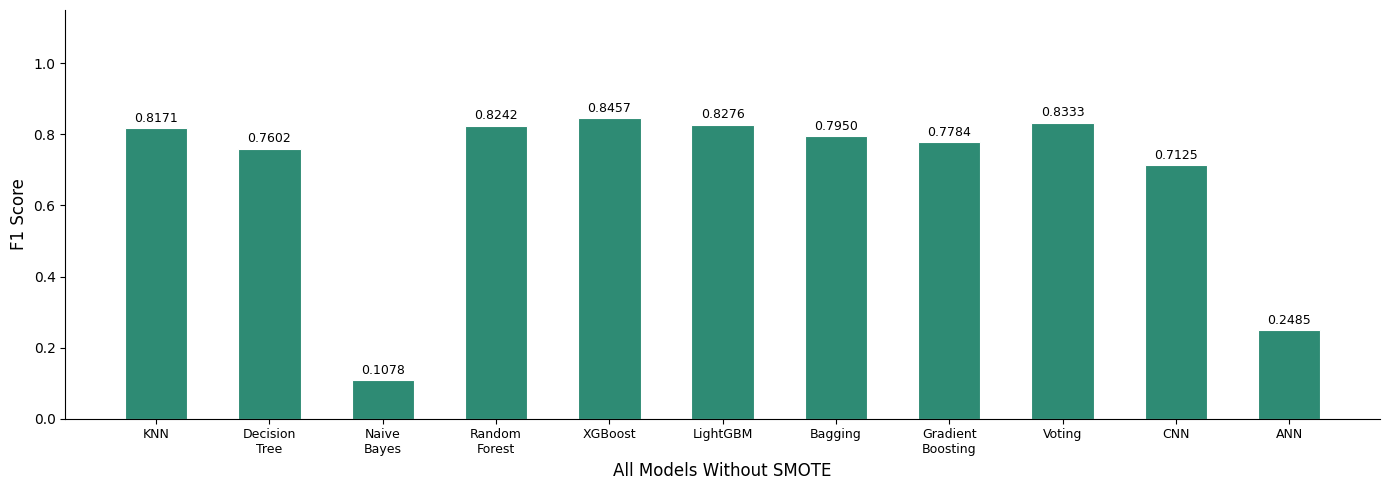

In [72]:
# -- Chart 5: All Models F1 — No SMOTE ----------------------------------------
model_order = [
    'KNN', 'Decision Tree', 'Naive Bayes',
    'Random Forest', 'XGBoost', 'LightGBM',
    'Bagging', 'Gradient Boosting', 'Voting',
    'CNN', 'ANN'
]
model_labels = [
    'KNN', 'Decision\nTree', 'Naive\nBayes',
    'Random\nForest', 'XGBoost', 'LightGBM',
    'Bagging', 'Gradient\nBoosting', 'Voting',
    'CNN', 'ANN'
]

no_smote_dict = {r['Model']: r['F1'] for r in results_no_smote}

f1_no_smote = [
    round(next((v for k, v in no_smote_dict.items() if key in k), 0.0), 4)
    for key in model_order
]

x = np.arange(len(model_order))
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, f1_no_smote, width=0.55, color='#2E8B74', edgecolor='white', linewidth=0.8)
for bar, score in zip(bars, f1_no_smote):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, color='black')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('All Models Without SMOTE', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.savefig('all_models_no_smote.png', dpi=150, bbox_inches='tight')
plt.show()


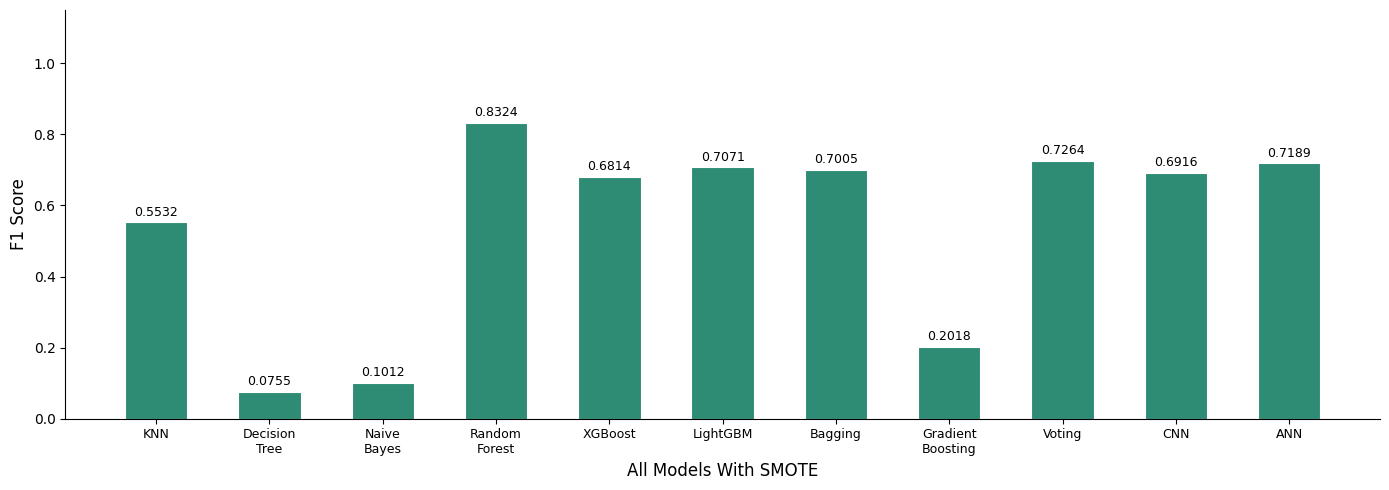

In [73]:
# -- Chart 6: All Models F1 — With SMOTE --------------------------------------
model_order = [
    'KNN', 'Decision Tree', 'Naive Bayes',
    'Random Forest', 'XGBoost', 'LightGBM',
    'Bagging', 'Gradient Boosting', 'Voting',
    'CNN', 'ANN'
]
model_labels = [
    'KNN', 'Decision\nTree', 'Naive\nBayes',
    'Random\nForest', 'XGBoost', 'LightGBM',
    'Bagging', 'Gradient\nBoosting', 'Voting',
    'CNN', 'ANN'
]

smote_dict = {r['Model']: r['F1'] for r in results_smote}

f1_smote = [
    round(next((v for k, v in smote_dict.items() if key in k), 0.0), 4)
    for key in model_order
]

x = np.arange(len(model_order))
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, f1_smote, width=0.55, color='#2E8B74', edgecolor='white', linewidth=0.8)
for bar, score in zip(bars, f1_smote):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9, color='black')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('All Models With SMOTE', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(False)
plt.tight_layout()
plt.savefig('all_models_smote.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Feature Importance

### 9.1 Random Forest feature importance

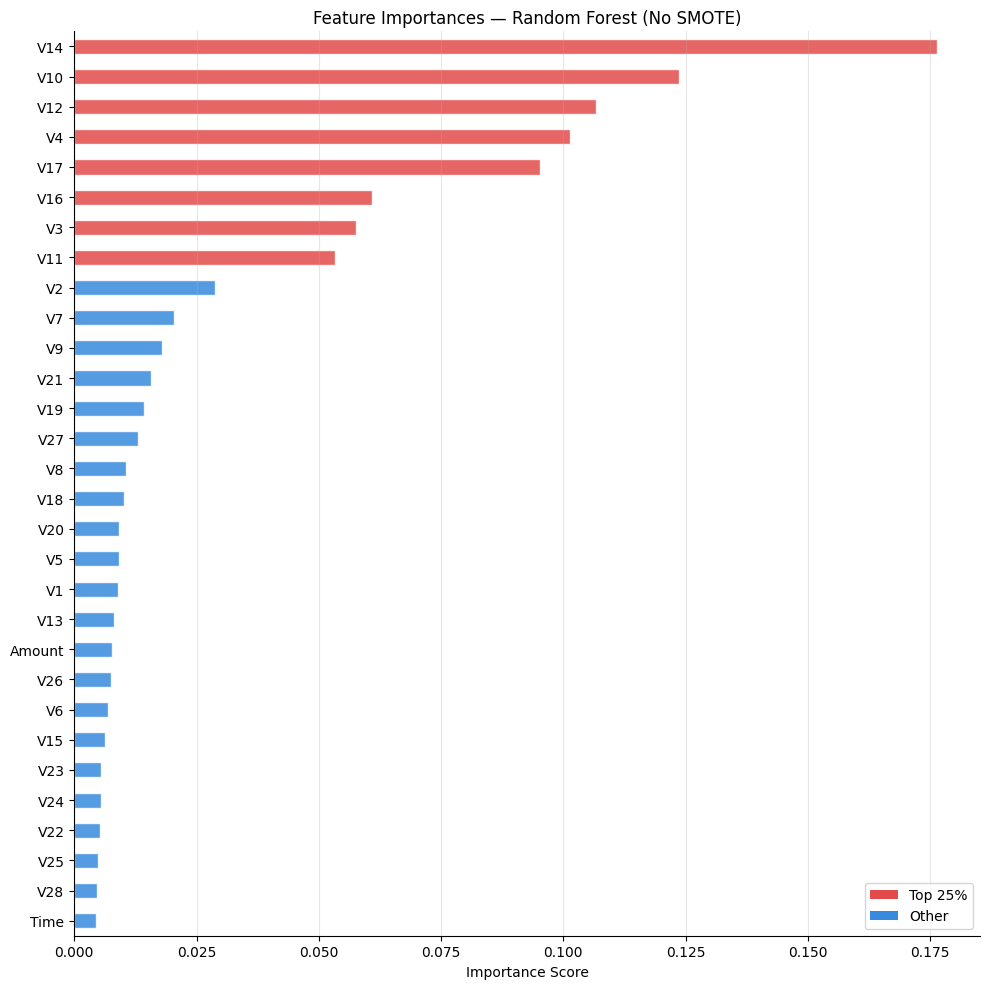


Top 10 most important features:
V14    0.1764
V10    0.1237
V12    0.1067
V4     0.1013
V17    0.0952
V16    0.0609
V3     0.0577
V11    0.0533
V2     0.0288
V7     0.0204


In [57]:
feat_names = X_train.columns.tolist()
feat_imp   = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors_fi = ['#E24B4A' if v > feat_imp.quantile(0.75) else '#378ADD' for v in feat_imp]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, alpha=0.85, edgecolor='white')
ax.set_title("Feature Importances — Random Forest (No SMOTE)", fontsize=12)
ax.set_xlabel("Importance Score")
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#E24B4A', label='Top 25%'),
                   Patch(facecolor='#378ADD', label='Other')], fontsize=10)
plt.tight_layout(); plt.show()

print("\nTop 10 most important features:")
print(feat_imp.sort_values(ascending=False).head(10).round(4).to_string())